
[O3N2-M13] offset statistics for NGC4383 (offsets relative to Σ* bin means):
  Σ_SFR global mean: -2.418
  Σ_SFR offset range: -1.057 to 2.161
  Σ_SFR offset max absolute: ±2.161
  [O/H] global mean: 8.390
  [O/H] offset range: -0.125 to 0.078
  [O/H] offset max absolute: ±0.125
  Number of Σ* bins: 12
  Valid pixels for Σ_SFR: 70639
  Valid pixels for [O/H]: 70639
  Common valid pixels: 70637


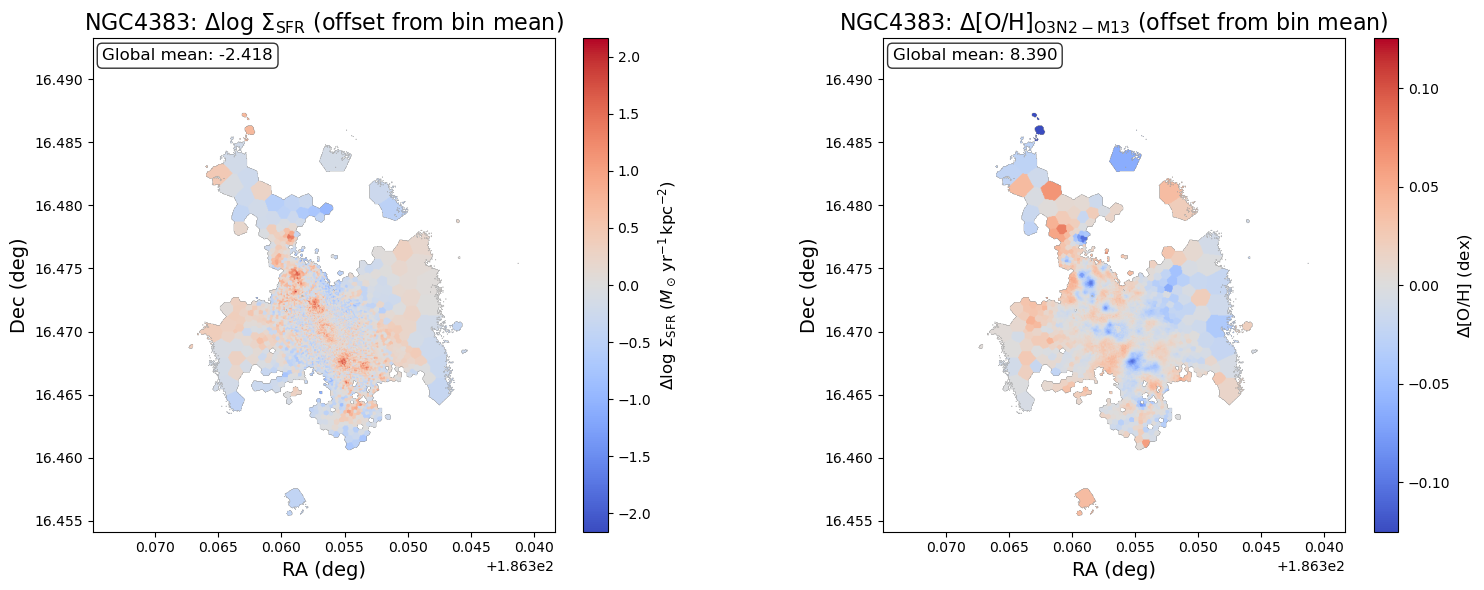

In [1]:
# ------------------------------------------------------------------
# 0.  Load NGC4383 maps and visualise Σ_SFR and [O/H] offset maps
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

# Only focus on NGC4383 for this visualisation
galaxies = ['NGC4383']

# ------------------------------------------------------------------
# 1.  Helper: read the required maps
# ------------------------------------------------------------------
def load_maps(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
        wcs = WCS(h_spatial['LOGMASS_SURFACE_DENSITY'].header)
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_O3N2_M14_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M14_HII'].data
            indicator_name = 'O3N2-M14'
        elif 'O_H_O3N2_M13_HII' in h_gas:
            print(f"Warning: O3N2-M14 not available for {gal}; using O3N2-M13 instead.")
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
            indicator_name = 'O3N2-M13'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No O3N2 metallicity extension (M14/M13) found for {gal}. Available: {available}")
        gas_header = h_gas['LOGSFR_SURFACE_DENSITY_HII'].header
    return sigM, sigSFR, oh_map, indicator_name, wcs, gas_header

for gal in galaxies:
    sigM, sigSFR, oh_o3n2_map, indicator_name, wcs_full, gas_header = load_maps(gal)

    # Valid pixels across maps
    valid_sfr = np.isfinite(sigSFR)
    valid_oh = np.isfinite(oh_o3n2_map)
    valid_sigM = np.isfinite(sigM)
    valid_all = valid_sfr & valid_oh & valid_sigM

    # ------------------------------------------------------------------
    # 2.  Calculate offset maps (relative to Σ* bin means)
    # ------------------------------------------------------------------
    # Define 12 Σ* bins
    n_bins = 12
    sigmaM_min = np.nanmin(sigM[valid_all])
    sigmaM_max = np.nanmax(sigM[valid_all])
    sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)
    
    # Initialize offset maps
    sfr_offset = np.full_like(sigSFR, np.nan)
    oh_offset = np.full_like(oh_o3n2_map, np.nan)
    
    # Calculate offset for each Σ* bin
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        
        if np.sum(bin_mask) > 0:
            # Calculate bin mean and offset within this bin
            sfr_bin_mean = np.mean(sigSFR[bin_mask])
            oh_bin_mean = np.mean(oh_o3n2_map[bin_mask])
            
            sfr_offset[bin_mask] = sigSFR[bin_mask] - sfr_bin_mean
            oh_offset[bin_mask] = oh_o3n2_map[bin_mask] - oh_bin_mean
    
    # Calculate symmetric colorbar limits for offset maps
    sfr_offset_max = np.nanmax(np.abs(sfr_offset[valid_all]))
    oh_offset_max = np.nanmax(np.abs(oh_offset[valid_all]))
    
    # Global means for display purposes only
    sfr_mean_global = np.nanmean(sigSFR[valid_sfr])
    oh_mean_global = np.nanmean(oh_o3n2_map[valid_oh])

    # ------------------------------------------------------------------
    # 3.  Prepare coordinate extent for plotting (RA/Dec degrees)
    # ------------------------------------------------------------------
    wcs_celestial = WCS(gas_header).celestial
    y_size, x_size = sigSFR.shape
    x_coords = np.arange(x_size)
    y_coords = np.arange(y_size)
    xx, yy = np.meshgrid(x_coords, y_coords)
    ra, dec = wcs_celestial.pixel_to_world_values(xx, yy)
    extent = [ra.max(), ra.min(), dec.min(), dec.max()]

    # ------------------------------------------------------------------
    # 4.  Create figure: left = Σ_SFR offset, right = [O/H] offset
    # ------------------------------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Left-hand side: Σ_SFR offset map (coolwarm, centered at 0)
    im_sfr = axes[0].imshow(np.ma.masked_invalid(sfr_offset), origin='lower', cmap='coolwarm',
                            extent=extent, vmin=-sfr_offset_max, vmax=sfr_offset_max)
    axes[0].set_title(rf'{gal}: $\Delta\log\,\Sigma_{{\mathrm{{SFR}}}}$ (offset from bin mean)', fontsize=16)
    axes[0].set_xlabel('RA (deg)', fontsize=14)
    axes[0].set_ylabel('Dec (deg)', fontsize=14)

    cbar_sfr = fig.colorbar(im_sfr, ax=axes[0], fraction=0.046, pad=0.04)
    cbar_sfr.set_label(r'$\Delta\log\,\Sigma_{\mathrm{SFR}} \; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=12)
    
    # Add global mean value annotation on top left
    axes[0].text(0.02, 0.98, f'Global mean: {sfr_mean_global:.3f}', transform=axes[0].transAxes, 
                fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # Right-hand side: [O/H] offset map (coolwarm, centered at 0)
    im_oh = axes[1].imshow(np.ma.masked_invalid(oh_offset), origin='lower', cmap='coolwarm',
                           extent=extent, vmin=-oh_offset_max, vmax=oh_offset_max)
    axes[1].set_title(rf'{gal}: $\Delta$[O/H]$_{{\mathrm{{{indicator_name}}}}}$ (offset from bin mean)', fontsize=16)
    axes[1].set_xlabel('RA (deg)', fontsize=14)
    axes[1].set_ylabel('Dec (deg)', fontsize=14)

    cbar_oh = fig.colorbar(im_oh, ax=axes[1], fraction=0.046, pad=0.04)
    cbar_oh.set_label(r'$\Delta$[O/H] (dex)', fontsize=12)
    
    # Add global mean value annotation on top left
    axes[1].text(0.02, 0.98, f'Global mean: {oh_mean_global:.3f}', transform=axes[1].transAxes, 
                fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # For reporting: offset statistics for the maps
    print(f"\n[{indicator_name}] offset statistics for {gal} (offsets relative to Σ* bin means):")
    print(f"  Σ_SFR global mean: {sfr_mean_global:.3f}")
    print(f"  Σ_SFR offset range: {np.nanmin(sfr_offset[valid_all]):.3f} to {np.nanmax(sfr_offset[valid_all]):.3f}")
    print(f"  Σ_SFR offset max absolute: ±{sfr_offset_max:.3f}")
    print(f"  [O/H] global mean: {oh_mean_global:.3f}")
    print(f"  [O/H] offset range: {np.nanmin(oh_offset[valid_all]):.3f} to {np.nanmax(oh_offset[valid_all]):.3f}")
    print(f"  [O/H] offset max absolute: ±{oh_offset_max:.3f}")
    print(f"  Number of Σ* bins: {n_bins}")
    print(f"  Valid pixels for Σ_SFR: {np.sum(valid_sfr)}")
    print(f"  Valid pixels for [O/H]: {np.sum(valid_oh)}")
    print(f"  Common valid pixels: {np.sum(valid_all)}")

    plt.tight_layout()
    # plt.savefig(f'{gal}_SigmaSFR_and_OH_offset_maps.png', dpi=600)
    plt.show()

/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_32329/4259751925.py:231: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


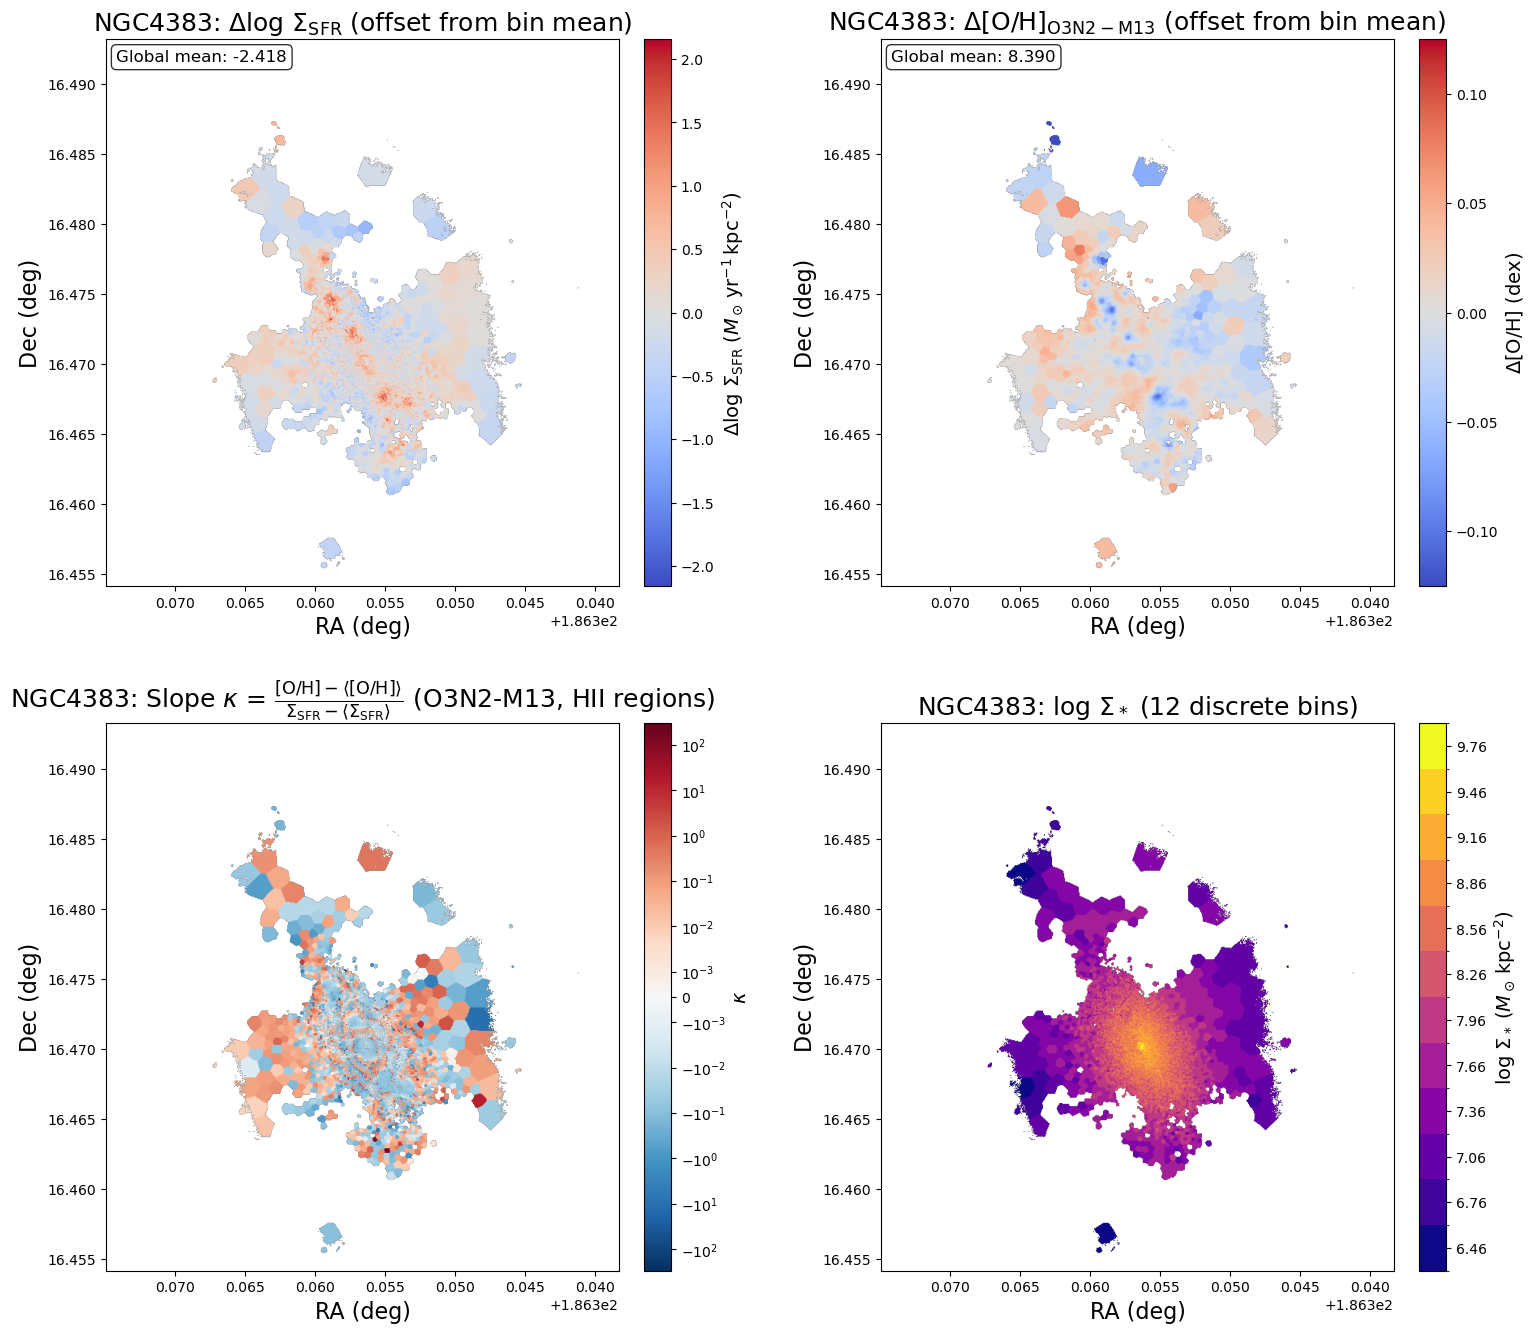


2x2 combined figure complete for NGC4383!
  Σ_SFR offset range: -2.161 to 2.161
  [O/H] offset range: -0.125 to 0.125
  κ range: -169.334 to 298.096
  Σ* bins: 12 bins from 6.315 to 9.905


In [2]:
# ------------------------------------------------------------------
# 2x2 Combined figure: offset maps + slope map + binned Σ* map
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gs_module
from matplotlib.colors import BoundaryNorm, SymLogNorm

# Only focus on NGC4383 for this visualisation
galaxies = ['NGC4383']

# ------------------------------------------------------------------
# 1.  Helper: read the required maps
# ------------------------------------------------------------------
def load_maps(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
        wcs = WCS(h_spatial['LOGMASS_SURFACE_DENSITY'].header)
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_O3N2_M14_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M14_HII'].data
            indicator_name = 'O3N2-M14'
        elif 'O_H_O3N2_M13_HII' in h_gas:
            print(f"Warning: O3N2-M14 not available for {gal}; using O3N2-M13 instead.")
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
            indicator_name = 'O3N2-M13'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No O3N2 metallicity extension (M14/M13) found for {gal}. Available: {available}")
        gas_header = h_gas['LOGSFR_SURFACE_DENSITY_HII'].header
    return sigM, sigSFR, oh_map, indicator_name, wcs, gas_header

for gal in galaxies:
    sigM, sigSFR, oh_o3n2_map, indicator_name, wcs_full, gas_header = load_maps(gal)

    # Valid pixels across maps
    valid_sfr = np.isfinite(sigSFR)
    valid_oh = np.isfinite(oh_o3n2_map)
    valid_sigM = np.isfinite(sigM)
    valid_all = valid_sfr & valid_oh & valid_sigM

    # ------------------------------------------------------------------
    # 2.  Calculate offset maps (relative to Σ* bin means)
    # ------------------------------------------------------------------
    # Define 12 Σ* bins
    n_bins = 12
    sigmaM_min = np.nanmin(sigM[valid_all])
    sigmaM_max = np.nanmax(sigM[valid_all])
    sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)
    
    # Initialize offset maps
    sfr_offset = np.full_like(sigSFR, np.nan)
    oh_offset = np.full_like(oh_o3n2_map, np.nan)
    
    # Calculate offset for each Σ* bin
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        
        if np.sum(bin_mask) > 0:
            # Calculate bin mean and offset within this bin
            sfr_bin_mean = np.mean(sigSFR[bin_mask])
            oh_bin_mean = np.mean(oh_o3n2_map[bin_mask])
            
            sfr_offset[bin_mask] = sigSFR[bin_mask] - sfr_bin_mean
            oh_offset[bin_mask] = oh_o3n2_map[bin_mask] - oh_bin_mean
    
    sfr_offset_max = np.nanmax(np.abs(sfr_offset[valid_all]))
    oh_offset_max = np.nanmax(np.abs(oh_offset[valid_all]))
    
    # Global means for display purposes only
    sfr_mean = np.nanmean(sigSFR[valid_sfr])
    oh_mean = np.nanmean(oh_o3n2_map[valid_oh])

    # ------------------------------------------------------------------
    # 3.  Calculate slope κ map
    # ------------------------------------------------------------------
    # Note: n_bins, sigmaM_bin_edges already defined in section 2
    kappa_map = np.full_like(sigM, np.nan)
    
    sigM_flat = sigM.flatten()
    sigSFR_flat = sigSFR.flatten()
    oh_flat = oh_o3n2_map.flatten()
    valid_all_flat = valid_all.flatten()
    kappa_flat = np.full_like(sigM_flat, np.nan)
    
    for i in range(n_bins):
        if i == 0:
            in_bin = (sigM_flat >= sigmaM_bin_edges[i]) & (sigM_flat < sigmaM_bin_edges[i+1]) & valid_all_flat
        elif i == n_bins - 1:
            in_bin = (sigM_flat >= sigmaM_bin_edges[i]) & (sigM_flat <= sigmaM_bin_edges[i+1]) & valid_all_flat
        else:
            in_bin = (sigM_flat >= sigmaM_bin_edges[i]) & (sigM_flat < sigmaM_bin_edges[i+1]) & valid_all_flat
        
        if np.sum(in_bin) > 0:
            x_bin = sigSFR_flat[in_bin]
            y_bin = oh_flat[in_bin]
            
            # Calculate the mean point: (x₀, y₀) = (mean(ΣSFR), mean([O/H]))
            x0 = np.mean(x_bin)
            y0 = np.mean(y_bin)
            
            dx = x_bin - x0
            dy = y_bin - y0
            
            kappa_bin = np.zeros_like(dx)
            nonzero_dx = np.abs(dx) > 1e-10
            kappa_bin[nonzero_dx] = dy[nonzero_dx] / dx[nonzero_dx]
            kappa_bin[~nonzero_dx] = 0
            
            kappa_flat[in_bin] = kappa_bin
    
    kappa_map = kappa_flat.reshape(sigM.shape)

    # ------------------------------------------------------------------
    # 4.  Create binned Σ* map
    # ------------------------------------------------------------------
    sigM_binned_map = np.full_like(sigM, np.nan)
    
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        
        # Assign bin center value
        bin_center = (sigmaM_bin_edges[i] + sigmaM_bin_edges[i+1]) / 2
        sigM_binned_map[bin_mask] = bin_center

    # ------------------------------------------------------------------
    # 5.  Prepare coordinate extent
    # ------------------------------------------------------------------
    wcs_celestial = WCS(gas_header).celestial
    y_size, x_size = sigSFR.shape
    x_coords = np.arange(x_size)
    y_coords = np.arange(y_size)
    xx, yy = np.meshgrid(x_coords, y_coords)
    ra, dec = wcs_celestial.pixel_to_world_values(xx, yy)
    extent = [ra.max(), ra.min(), dec.min(), dec.max()]

    # ------------------------------------------------------------------
    # 6.  Create 2x2 figure
    # ------------------------------------------------------------------
    fig = plt.figure(figsize=(18, 16))
    gs = gs_module.GridSpec(2, 2, figure=fig, hspace=0.25, wspace=0.25)

    # Top-left: Σ_SFR offset map
    ax1 = fig.add_subplot(gs[0, 0])
    im_sfr = ax1.imshow(np.ma.masked_invalid(sfr_offset), origin='lower', cmap='coolwarm',
                        extent=extent, vmin=-sfr_offset_max, vmax=sfr_offset_max)
    ax1.set_title(rf'{gal}: $\Delta\log\,\Sigma_{{\mathrm{{SFR}}}}$ (offset from bin mean)', fontsize=18)
    ax1.set_xlabel('RA (deg)', fontsize=16)
    ax1.set_ylabel('Dec (deg)', fontsize=16)
    
    cbar_sfr = fig.colorbar(im_sfr, ax=ax1, fraction=0.046, pad=0.04)
    cbar_sfr.set_label(r'$\Delta\log\,\Sigma_{\mathrm{SFR}} \; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=14)
    
    ax1.text(0.02, 0.98, f'Global mean: {sfr_mean:.3f}', transform=ax1.transAxes, 
            fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # Top-right: [O/H] offset map
    ax2 = fig.add_subplot(gs[0, 1])
    im_oh = ax2.imshow(np.ma.masked_invalid(oh_offset), origin='lower', cmap='coolwarm',
                       extent=extent, vmin=-oh_offset_max, vmax=oh_offset_max)
    ax2.set_title(rf'{gal}: $\Delta$[O/H]$_{{\mathrm{{{indicator_name}}}}}$ (offset from bin mean)', fontsize=18)
    ax2.set_xlabel('RA (deg)', fontsize=16)
    ax2.set_ylabel('Dec (deg)', fontsize=16)
    
    cbar_oh = fig.colorbar(im_oh, ax=ax2, fraction=0.046, pad=0.04)
    cbar_oh.set_label(r'$\Delta$[O/H] (dex)', fontsize=14)
    
    ax2.text(0.02, 0.98, f'Global mean: {oh_mean:.3f}', transform=ax2.transAxes, 
            fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # Bottom-left: Slope κ map with SymLogNorm
    ax3 = fig.add_subplot(gs[1, 0])
    
    kappa_max = np.nanmax(np.abs(kappa_map[valid_all]))
    linthresh = 0.001
    linscale = 0.5
    
    norm_kappa = SymLogNorm(linthresh=linthresh, linscale=linscale, 
                            vmin=-kappa_max, vmax=kappa_max)
    
    im_kappa = ax3.imshow(np.ma.masked_invalid(kappa_map), origin='lower', cmap='RdBu_r',
                          extent=extent, norm=norm_kappa)
    ax3.set_title(rf'{gal}: Slope $\kappa$ = $\frac{{[\mathrm{{O/H}}] - \langle[\mathrm{{O/H}}]\rangle}}{{\Sigma_{{\mathrm{{SFR}}}} - \langle\Sigma_{{\mathrm{{SFR}}}}\rangle}}$ ({indicator_name}, HII regions)', 
                  fontsize=18)
    ax3.set_xlabel('RA (deg)', fontsize=16)
    ax3.set_ylabel('Dec (deg)', fontsize=16)
    
    cbar_kappa = fig.colorbar(im_kappa, ax=ax3, fraction=0.046, pad=0.04)
    cbar_kappa.set_label(r'$\kappa$', fontsize=14)

    # Bottom-right: Discrete Σ* binned map
    ax4 = fig.add_subplot(gs[1, 1])
    
    cmap_discrete = plt.cm.plasma
    norm_discrete = BoundaryNorm(sigmaM_bin_edges, cmap_discrete.N)
    
    im_sigM_binned = ax4.imshow(np.ma.masked_invalid(sigM_binned_map), origin='lower', 
                                cmap=cmap_discrete, norm=norm_discrete, extent=extent)
    ax4.set_title(rf'{gal}: $\log\,\Sigma_*$ ({n_bins} discrete bins)', fontsize=18)
    ax4.set_xlabel('RA (deg)', fontsize=16)
    ax4.set_ylabel('Dec (deg)', fontsize=16)
    
    cbar_binned = fig.colorbar(im_sigM_binned, ax=ax4, fraction=0.046, pad=0.04)
    cbar_binned.set_label(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=14)
    
    # Set colorbar ticks at bin centers
    bin_centers = [(sigmaM_bin_edges[i] + sigmaM_bin_edges[i+1]) / 2 for i in range(n_bins)]
    cbar_binned.set_ticks(bin_centers)
    cbar_binned.set_ticklabels([f'{bc:.2f}' for bc in bin_centers])

    plt.tight_layout()
    plt.savefig(f'{gal}_correlation_map_kappa.png', dpi=600, bbox_inches='tight')
    plt.savefig(f'{gal}_correlation_map_kappa.pdf', bbox_inches='tight')
    plt.show()

    print(f"\n2x2 combined figure complete for {gal}!")
    print(f"  Σ_SFR offset range: {-sfr_offset_max:.3f} to {sfr_offset_max:.3f}")
    print(f"  [O/H] offset range: {-oh_offset_max:.3f} to {oh_offset_max:.3f}")
    print(f"  κ range: {np.nanmin(kappa_map[valid_all]):.3f} to {np.nanmax(kappa_map[valid_all]):.3f}")
    print(f"  Σ* bins: {n_bins} bins from {sigmaM_min:.3f} to {sigmaM_max:.3f}")


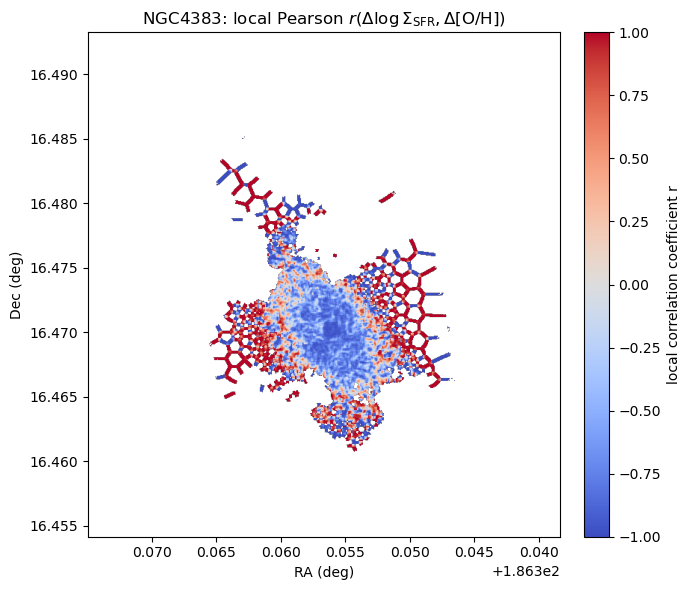

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def local_corr_map(A, B, valid_mask, half_win=2, min_n=10):
    """
    Compute a moving-window Pearson correlation between A and B.

    Parameters
    ----------
    A, B : 2D arrays
        Maps (e.g. sfr_offset, oh_offset).
    valid_mask : 2D bool
        True where both maps are valid.
    half_win : int
        Half window size in pixels (half_win=2 -> 5x5 window).
    min_n : int
        Minimum number of valid pixels in the window to compute a correlation.

    Returns
    -------
    corr_map : 2D array
        Map of local Pearson correlation coefficients in [-1, 1].
    """
    ny, nx = A.shape
    corr_map = np.full_like(A, np.nan, dtype=float)

    for i in range(ny):
        i0 = max(0, i - half_win)
        i1 = min(ny, i + half_win + 1)
        for j in range(nx):
            if not valid_mask[i, j]:
                continue
            j0 = max(0, j - half_win)
            j1 = min(nx, j + half_win + 1)

            win_valid = valid_mask[i0:i1, j0:j1]
            if np.count_nonzero(win_valid) < min_n:
                continue

            a_vals = A[i0:i1, j0:j1][win_valid]
            b_vals = B[i0:i1, j0:j1][win_valid]

            # need at least 2 unique values to define correlation
            if np.std(a_vals) == 0 or np.std(b_vals) == 0:
                continue

            r = np.corrcoef(a_vals, b_vals)[0, 1]
            corr_map[i, j] = r

    return corr_map

# --- compute and plot for NGC4383 ---
A = sfr_offset
B = oh_offset
valid = valid_all

corr_map = local_corr_map(A, B, valid_mask=valid, half_win=2, min_n=10)

fig, ax = plt.subplots(figsize=(7, 6))
v = np.nanmax(np.abs(corr_map))  # symmetric colour range
im = ax.imshow(np.ma.masked_invalid(corr_map), origin='lower',
               cmap='coolwarm', extent=extent, vmin=-v, vmax=v)
ax.set_title(r'NGC4383: local Pearson $r(\Delta\log\Sigma_{\rm SFR}, \Delta{\rm [O/H]})$')
ax.set_xlabel('RA (deg)')
ax.set_ylabel('Dec (deg)')
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('local correlation coefficient r')

plt.tight_layout()
plt.show()


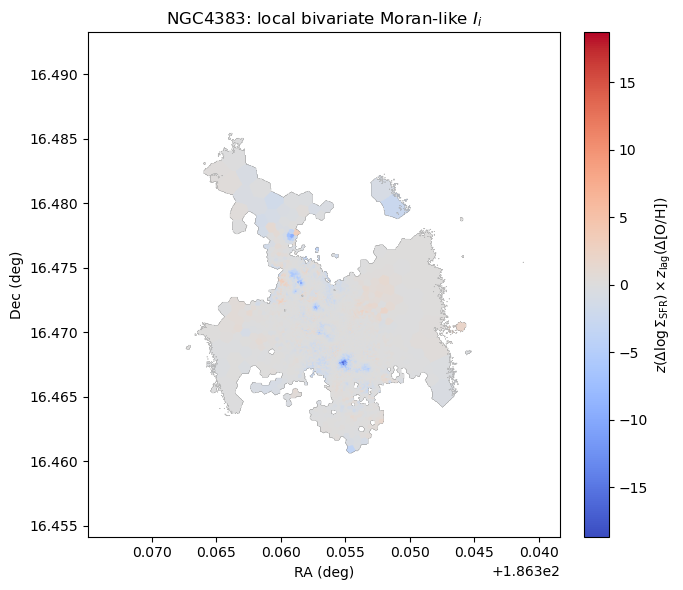

In [4]:
def local_bivariate_moran_by_bin(A, B, valid_mask, binid_map, neighbourhood='queen'):
    """Local bivariate Moran-style statistic on adjacent spatial bins.

    Each valid BINID is treated as one graph node, using the mean A and B value
    of that bin. The resulting per-bin Moran value is expanded back to all
    valid pixels in the bin for plotting.
    """
    A = np.asarray(A, dtype=float)
    B = np.asarray(B, dtype=float)
    valid_mask = np.asarray(valid_mask, dtype=bool)
    binid_raw = np.asarray(binid_map, dtype=float)
    if A.shape != B.shape or A.shape != valid_mask.shape or A.shape != binid_raw.shape:
        raise ValueError('A, B, valid_mask, and binid_map must have the same shape')

    I_map = np.full(A.shape, np.nan)
    quad_map = np.zeros(A.shape, dtype=np.int16)
    finite_bin = np.isfinite(binid_raw) & (binid_raw >= 0)
    binid = np.full(A.shape, -1, dtype=np.int64)
    binid[finite_bin] = np.rint(binid_raw[finite_bin]).astype(np.int64)
    valid = valid_mask & np.isfinite(A) & np.isfinite(B) & (binid >= 0)
    valid_bins = np.unique(binid[valid])
    if valid_bins.size < 2:
        return I_map, quad_map

    max_bin = int(valid_bins.max())
    flat_bins = binid[valid].ravel()
    counts = np.bincount(flat_bins, minlength=max_bin + 1).astype(float)
    sum_A = np.bincount(flat_bins, weights=A[valid].ravel(), minlength=max_bin + 1)
    sum_B = np.bincount(flat_bins, weights=B[valid].ravel(), minlength=max_bin + 1)
    A_bin = np.full(max_bin + 1, np.nan)
    B_bin = np.full(max_bin + 1, np.nan)
    has_data = counts > 0
    A_bin[has_data] = sum_A[has_data] / counts[has_data]
    B_bin[has_data] = sum_B[has_data] / counts[has_data]

    A_vals = A_bin[valid_bins]
    B_vals = B_bin[valid_bins]
    A_std = np.nanstd(A_vals)
    B_std = np.nanstd(B_vals)
    if not np.isfinite(A_std) or not np.isfinite(B_std) or A_std == 0 or B_std == 0:
        return I_map, quad_map

    Az = np.full(max_bin + 1, np.nan)
    Bz = np.full(max_bin + 1, np.nan)
    Az[valid_bins] = (A_vals - np.nanmean(A_vals)) / A_std
    Bz[valid_bins] = (B_vals - np.nanmean(B_vals)) / B_std

    offsets = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    if neighbourhood == 'queen':
        offsets += [(-1, -1), (-1, 1), (1, -1), (1, 1)]
    elif neighbourhood != 'rook':
        raise ValueError("neighbourhood must be 'rook' or 'queen'")

    adjacency = {int(b): set() for b in valid_bins}
    rows, cols = A.shape
    for dy, dx in offsets:
        y0 = max(0, -dy)
        y1 = rows - max(0, dy)
        x0 = max(0, -dx)
        x1 = cols - max(0, dx)
        src = (slice(y0, y1), slice(x0, x1))
        dst = (slice(y0 + dy, y1 + dy), slice(x0 + dx, x1 + dx))
        pair_valid = valid[src] & valid[dst] & (binid[src] != binid[dst])
        for left, right in zip(binid[src][pair_valid], binid[dst][pair_valid]):
            left = int(left)
            right = int(right)
            adjacency[left].add(right)
            adjacency[right].add(left)

    for b in valid_bins:
        b = int(b)
        neigh = sorted(adjacency[b])
        if not neigh:
            continue
        lag_B = np.nanmean(Bz[neigh])
        I_val = Az[b] * lag_B
        pixels = valid & (binid == b)
        I_map[pixels] = I_val
        if Az[b] >= 0 and lag_B >= 0:
            quad_map[pixels] = 1
        elif Az[b] < 0 and lag_B < 0:
            quad_map[pixels] = 2
        elif Az[b] >= 0 and lag_B < 0:
            quad_map[pixels] = 3
        else:
            quad_map[pixels] = 4

    return I_map, quad_map
from astropy.io import fits
with fits.open('NGC4383_SPATIAL_BINNING_maps_extended.fits') as h_spatial:
    binid_map = h_spatial['BINID'].data

# --- compute and plot for NGC4383 ---
I_map, quad_map = local_bivariate_moran_by_bin(sfr_offset, oh_offset, valid_all, binid_map,
                                        neighbourhood='queen')

# amplitude map
fig, ax = plt.subplots(figsize=(7, 6))
vI = np.nanmax(np.abs(I_map))
imI = ax.imshow(np.ma.masked_invalid(I_map), origin='lower',
                cmap='coolwarm', extent=extent, vmin=-vI, vmax=vI)
ax.set_title(r'NGC4383: local bivariate Moran-like $I_i$')
ax.set_xlabel('RA (deg)')
ax.set_ylabel('Dec (deg)')
cbarI = fig.colorbar(imI, ax=ax, fraction=0.046, pad=0.04)
cbarI.set_label(r'$z(\Delta\log\Sigma_{\rm SFR}) \times z_{\rm lag}(\Delta{\rm [O/H]})$')
plt.tight_layout()
plt.show()


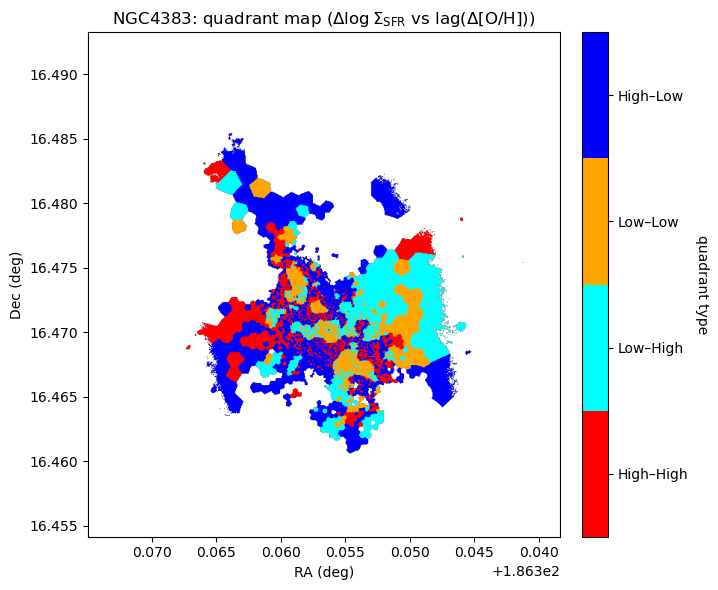

In [5]:
def local_bivariate_moran_by_bin(A, B, valid_mask, binid_map, neighbourhood='queen'):
    """Local bivariate Moran-style statistic on adjacent spatial bins.

    Each valid BINID is treated as one graph node, using the mean A and B value
    of that bin. The resulting per-bin Moran value is expanded back to all
    valid pixels in the bin for plotting.
    """
    A = np.asarray(A, dtype=float)
    B = np.asarray(B, dtype=float)
    valid_mask = np.asarray(valid_mask, dtype=bool)
    binid_raw = np.asarray(binid_map, dtype=float)
    if A.shape != B.shape or A.shape != valid_mask.shape or A.shape != binid_raw.shape:
        raise ValueError('A, B, valid_mask, and binid_map must have the same shape')

    I_map = np.full(A.shape, np.nan)
    quad_map = np.zeros(A.shape, dtype=np.int16)
    finite_bin = np.isfinite(binid_raw) & (binid_raw >= 0)
    binid = np.full(A.shape, -1, dtype=np.int64)
    binid[finite_bin] = np.rint(binid_raw[finite_bin]).astype(np.int64)
    valid = valid_mask & np.isfinite(A) & np.isfinite(B) & (binid >= 0)
    valid_bins = np.unique(binid[valid])
    if valid_bins.size < 2:
        return I_map, quad_map

    max_bin = int(valid_bins.max())
    flat_bins = binid[valid].ravel()
    counts = np.bincount(flat_bins, minlength=max_bin + 1).astype(float)
    sum_A = np.bincount(flat_bins, weights=A[valid].ravel(), minlength=max_bin + 1)
    sum_B = np.bincount(flat_bins, weights=B[valid].ravel(), minlength=max_bin + 1)
    A_bin = np.full(max_bin + 1, np.nan)
    B_bin = np.full(max_bin + 1, np.nan)
    has_data = counts > 0
    A_bin[has_data] = sum_A[has_data] / counts[has_data]
    B_bin[has_data] = sum_B[has_data] / counts[has_data]

    A_vals = A_bin[valid_bins]
    B_vals = B_bin[valid_bins]
    A_std = np.nanstd(A_vals)
    B_std = np.nanstd(B_vals)
    if not np.isfinite(A_std) or not np.isfinite(B_std) or A_std == 0 or B_std == 0:
        return I_map, quad_map

    Az = np.full(max_bin + 1, np.nan)
    Bz = np.full(max_bin + 1, np.nan)
    Az[valid_bins] = (A_vals - np.nanmean(A_vals)) / A_std
    Bz[valid_bins] = (B_vals - np.nanmean(B_vals)) / B_std

    offsets = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    if neighbourhood == 'queen':
        offsets += [(-1, -1), (-1, 1), (1, -1), (1, 1)]
    elif neighbourhood != 'rook':
        raise ValueError("neighbourhood must be 'rook' or 'queen'")

    adjacency = {int(b): set() for b in valid_bins}
    rows, cols = A.shape
    for dy, dx in offsets:
        y0 = max(0, -dy)
        y1 = rows - max(0, dy)
        x0 = max(0, -dx)
        x1 = cols - max(0, dx)
        src = (slice(y0, y1), slice(x0, x1))
        dst = (slice(y0 + dy, y1 + dy), slice(x0 + dx, x1 + dx))
        pair_valid = valid[src] & valid[dst] & (binid[src] != binid[dst])
        for left, right in zip(binid[src][pair_valid], binid[dst][pair_valid]):
            left = int(left)
            right = int(right)
            adjacency[left].add(right)
            adjacency[right].add(left)

    for b in valid_bins:
        b = int(b)
        neigh = sorted(adjacency[b])
        if not neigh:
            continue
        lag_B = np.nanmean(Bz[neigh])
        I_val = Az[b] * lag_B
        pixels = valid & (binid == b)
        I_map[pixels] = I_val
        if Az[b] >= 0 and lag_B >= 0:
            quad_map[pixels] = 1
        elif Az[b] < 0 and lag_B < 0:
            quad_map[pixels] = 2
        elif Az[b] >= 0 and lag_B < 0:
            quad_map[pixels] = 3
        else:
            quad_map[pixels] = 4

    return I_map, quad_map
from astropy.io import fits
with fits.open('NGC4383_SPATIAL_BINNING_maps_extended.fits') as h_spatial:
    binid_map = h_spatial['BINID'].data

# --- compute and plot for NGC4383 ---
I_map, quad_map = local_bivariate_moran_by_bin(sfr_offset, oh_offset, valid_all, binid_map,
                                        neighbourhood='queen')

# quad_map values:
# 0 = invalid / no neighbours
# 1 = High A – High lag(B)   (High–High)
# 2 = Low A  – High lag(B)   (Low–High)
# 3 = Low A  – Low lag(B)    (Low–Low)
# 4 = High A – Low lag(B)    (High–Low)

# mask invalid
quad_valid = np.where(quad_map == 0, np.nan, quad_map)

# we shift values from {1,2,3,4} -> {0,1,2,3} for nicer colourbar
quad_display = quad_valid - 1

quad_cmap = ListedColormap(['red', 'cyan', 'orange', 'blue'])
bounds = np.array([-0.5, 0.5, 1.5, 2.5, 3.5])  # bin edges
ticks = np.array([0, 1, 2, 3])                 # centres
ticklabels = ['High–High', 'Low–High', 'Low–Low', 'High–Low']

fig, ax = plt.subplots(figsize=(7, 6))
imQ = ax.imshow(np.ma.masked_invalid(quad_display),
                origin='lower', extent=extent,
                cmap=quad_cmap, vmin=-0.5, vmax=3.5)

ax.set_title(r'NGC4383: quadrant map ($\Delta\log\Sigma_{\rm SFR}$ vs lag($\Delta{\rm [O/H]}$))')
ax.set_xlabel('RA (deg)')
ax.set_ylabel('Dec (deg)')

cbarQ = fig.colorbar(imQ, ax=ax, boundaries=bounds, ticks=ticks,
                     fraction=0.046, pad=0.04)
cbarQ.ax.set_yticklabels(ticklabels)
cbarQ.set_label('quadrant type', rotation=270, labelpad=15)

plt.tight_layout()
plt.show()


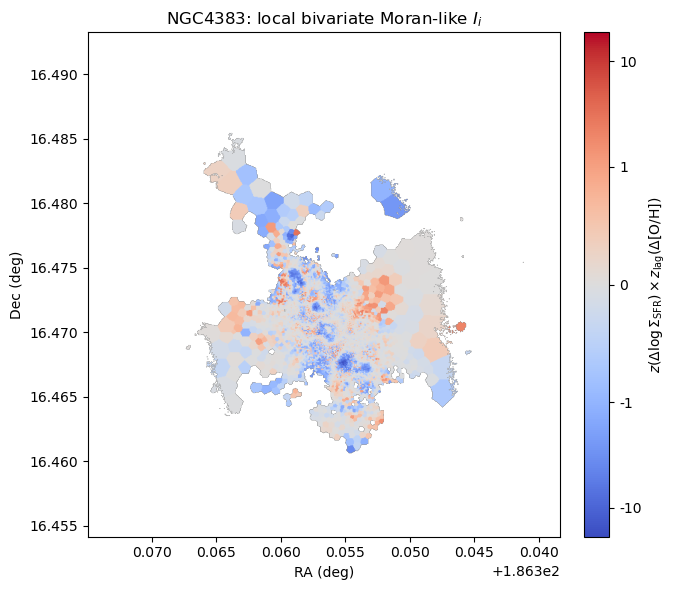

In [6]:
def local_bivariate_moran_by_bin(A, B, valid_mask, binid_map, neighbourhood='queen'):
    """Local bivariate Moran-style statistic on adjacent spatial bins.

    Each valid BINID is treated as one graph node, using the mean A and B value
    of that bin. The resulting per-bin Moran value is expanded back to all
    valid pixels in the bin for plotting.
    """
    A = np.asarray(A, dtype=float)
    B = np.asarray(B, dtype=float)
    valid_mask = np.asarray(valid_mask, dtype=bool)
    binid_raw = np.asarray(binid_map, dtype=float)
    if A.shape != B.shape or A.shape != valid_mask.shape or A.shape != binid_raw.shape:
        raise ValueError('A, B, valid_mask, and binid_map must have the same shape')

    I_map = np.full(A.shape, np.nan)
    quad_map = np.zeros(A.shape, dtype=np.int16)
    finite_bin = np.isfinite(binid_raw) & (binid_raw >= 0)
    binid = np.full(A.shape, -1, dtype=np.int64)
    binid[finite_bin] = np.rint(binid_raw[finite_bin]).astype(np.int64)
    valid = valid_mask & np.isfinite(A) & np.isfinite(B) & (binid >= 0)
    valid_bins = np.unique(binid[valid])
    if valid_bins.size < 2:
        return I_map, quad_map

    max_bin = int(valid_bins.max())
    flat_bins = binid[valid].ravel()
    counts = np.bincount(flat_bins, minlength=max_bin + 1).astype(float)
    sum_A = np.bincount(flat_bins, weights=A[valid].ravel(), minlength=max_bin + 1)
    sum_B = np.bincount(flat_bins, weights=B[valid].ravel(), minlength=max_bin + 1)
    A_bin = np.full(max_bin + 1, np.nan)
    B_bin = np.full(max_bin + 1, np.nan)
    has_data = counts > 0
    A_bin[has_data] = sum_A[has_data] / counts[has_data]
    B_bin[has_data] = sum_B[has_data] / counts[has_data]

    A_vals = A_bin[valid_bins]
    B_vals = B_bin[valid_bins]
    A_std = np.nanstd(A_vals)
    B_std = np.nanstd(B_vals)
    if not np.isfinite(A_std) or not np.isfinite(B_std) or A_std == 0 or B_std == 0:
        return I_map, quad_map

    Az = np.full(max_bin + 1, np.nan)
    Bz = np.full(max_bin + 1, np.nan)
    Az[valid_bins] = (A_vals - np.nanmean(A_vals)) / A_std
    Bz[valid_bins] = (B_vals - np.nanmean(B_vals)) / B_std

    offsets = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    if neighbourhood == 'queen':
        offsets += [(-1, -1), (-1, 1), (1, -1), (1, 1)]
    elif neighbourhood != 'rook':
        raise ValueError("neighbourhood must be 'rook' or 'queen'")

    adjacency = {int(b): set() for b in valid_bins}
    rows, cols = A.shape
    for dy, dx in offsets:
        y0 = max(0, -dy)
        y1 = rows - max(0, dy)
        x0 = max(0, -dx)
        x1 = cols - max(0, dx)
        src = (slice(y0, y1), slice(x0, x1))
        dst = (slice(y0 + dy, y1 + dy), slice(x0 + dx, x1 + dx))
        pair_valid = valid[src] & valid[dst] & (binid[src] != binid[dst])
        for left, right in zip(binid[src][pair_valid], binid[dst][pair_valid]):
            left = int(left)
            right = int(right)
            adjacency[left].add(right)
            adjacency[right].add(left)

    for b in valid_bins:
        b = int(b)
        neigh = sorted(adjacency[b])
        if not neigh:
            continue
        lag_B = np.nanmean(Bz[neigh])
        I_val = Az[b] * lag_B
        pixels = valid & (binid == b)
        I_map[pixels] = I_val
        if Az[b] >= 0 and lag_B >= 0:
            quad_map[pixels] = 1
        elif Az[b] < 0 and lag_B < 0:
            quad_map[pixels] = 2
        elif Az[b] >= 0 and lag_B < 0:
            quad_map[pixels] = 3
        else:
            quad_map[pixels] = 4

    return I_map, quad_map
from astropy.io import fits
with fits.open('NGC4383_SPATIAL_BINNING_maps_extended.fits') as h_spatial:
    binid_map = h_spatial['BINID'].data

# --- compute and plot for NGC4383 ---
I_map, quad_map = local_bivariate_moran_by_bin(sfr_offset, oh_offset, valid_all, binid_map,
                                        neighbourhood='queen')

fig, ax = plt.subplots(figsize=(7, 6))

# max absolute value for symmetric limits
vI = np.nanmax(np.abs(I_map))

# Symmetric log-normalisation:
#  - linthresh=1.0   → values between -1 and 1 are on a linear scale
#  - outside this, log10 scaling, symmetric around 0
norm = SymLogNorm(linthresh=1.0, linscale=1.0,
                  vmin=-vI, vmax=vI, base=10)

imI = ax.imshow(np.ma.masked_invalid(I_map), origin='lower',
                cmap='coolwarm', extent=extent, norm=norm)

ax.set_title(r'NGC4383: local bivariate Moran-like $I_i$')
ax.set_xlabel('RA (deg)')
ax.set_ylabel('Dec (deg)')

cbarI = fig.colorbar(imI, ax=ax, fraction=0.046, pad=0.04)
cbarI.set_label(r'$z(\Delta\log\Sigma_{\rm SFR}) \times z_{\rm lag}(\Delta{\rm [O/H]})$')

# Nice symmetric log-style ticks (…,-10,-3,-1,0,1,3,10,…)
max_pow = int(np.floor(np.log10(vI)))
pos_ticks = [10**k for k in range(0, max_pow+1) if 10**k <= vI]
ticks = [-p for p in reversed(pos_ticks)] + [0.0] + pos_ticks
cbarI.set_ticks(ticks)
cbarI.set_ticklabels([f'{t:g}' for t in ticks])

plt.tight_layout()
plt.show()


/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_32329/451977679.py:349: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


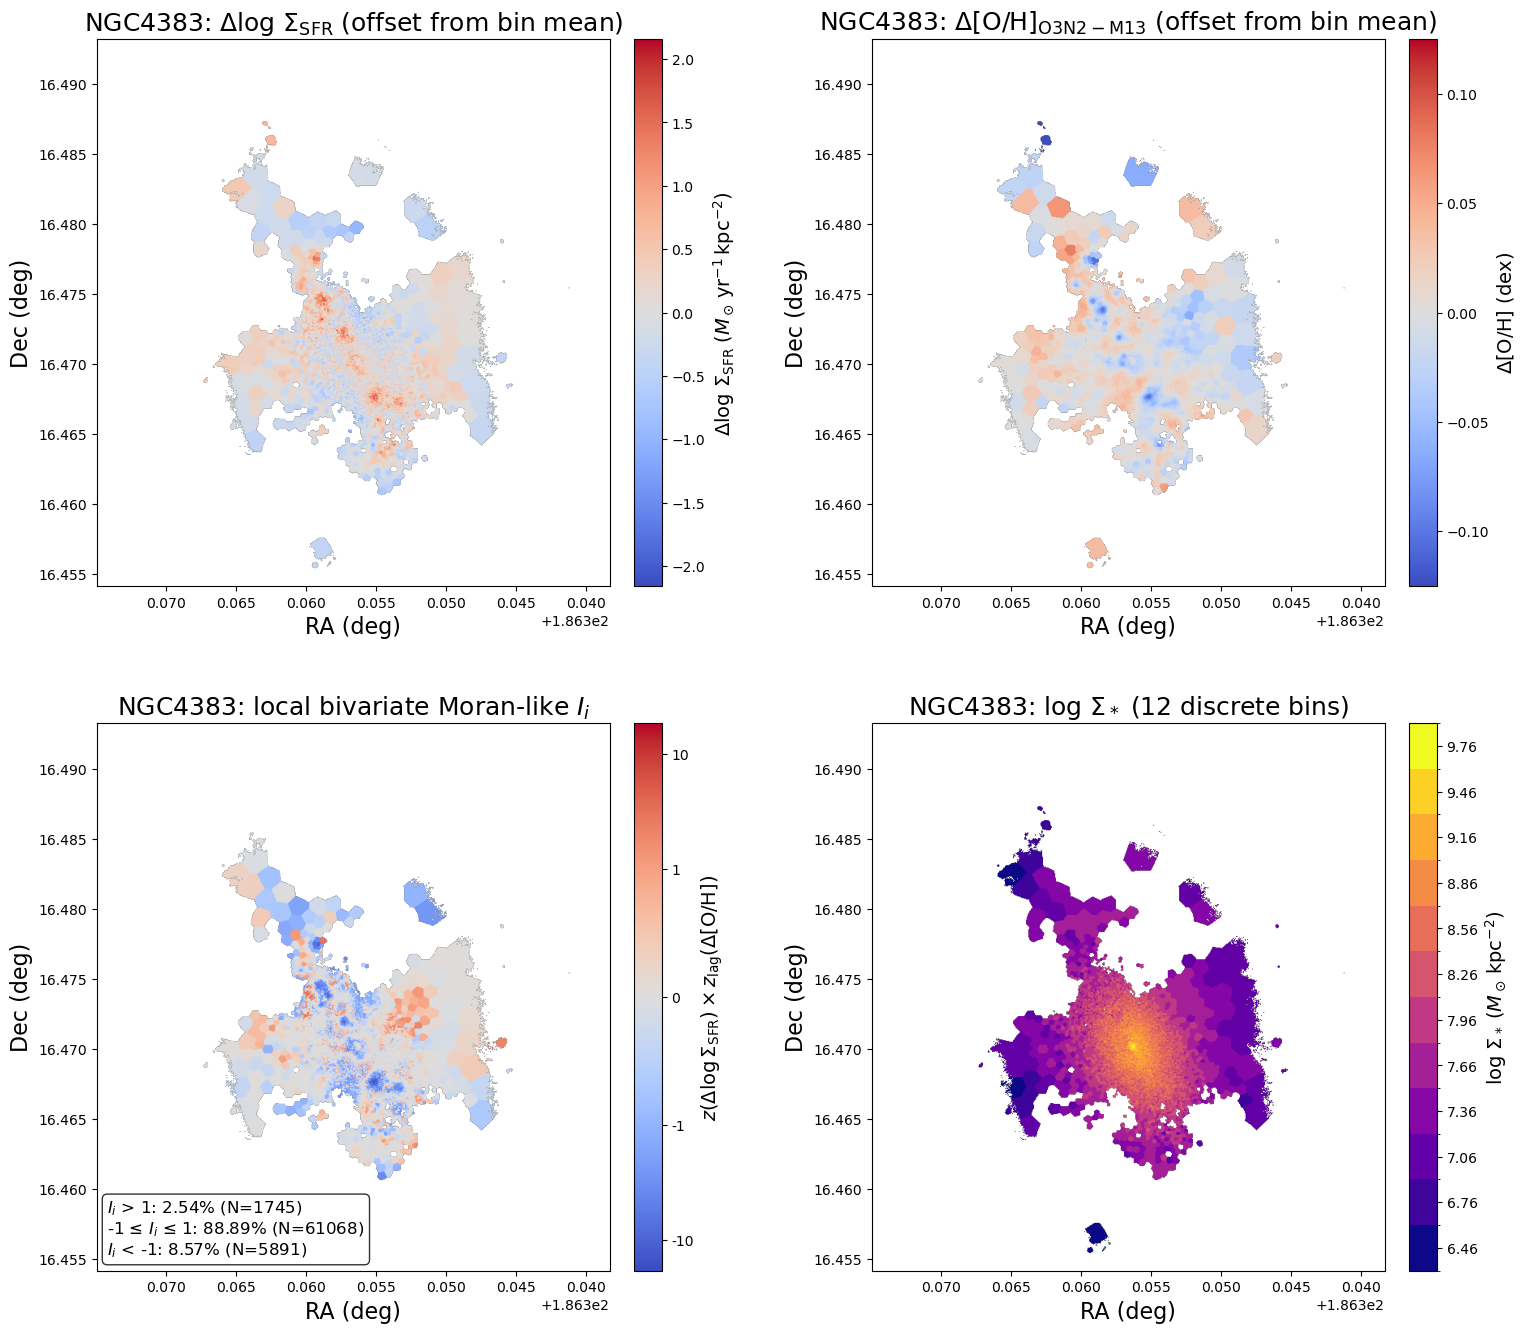


2x2 combined figure complete for NGC4383!
  Σ_SFR offset range: -2.161 to 2.161
  [O/H] offset range: -0.125 to 0.125
  Moran I_i range: -18.683 to 3.612
  Σ* bins: 12 bins from 6.315 to 9.905
  I_i > 1: 2.54% (N=1745)
  -1 ≤ I_i ≤ 1: 88.89% (N=61068)
  I_i < -1: 8.57% (N=5891)


In [7]:
# ------------------------------------------------------------------
# 2x2 Combined figure: offset maps + Moran-like map + binned Σ* map
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gs_module
from matplotlib.colors import BoundaryNorm, SymLogNorm

# Only focus on NGC4383 for this visualisation
galaxies = ['NGC4383']

# ------------------------------------------------------------------
# Define threshold parameter for linear/log colorbar transition and classification
# ------------------------------------------------------------------
threshold = 1  # Values between -threshold and +threshold use linear scale

# ------------------------------------------------------------------
# 1.  Helper: read the required maps
# ------------------------------------------------------------------
def load_maps(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
        binid_map = h_spatial['BINID'].data
        wcs = WCS(h_spatial['LOGMASS_SURFACE_DENSITY'].header)
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_O3N2_M14_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M14_HII'].data
            indicator_name = 'O3N2-M14'
        elif 'O_H_O3N2_M13_HII' in h_gas:
            print(f"Warning: O3N2-M14 not available for {gal}; using O3N2-M13 instead.")
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
            indicator_name = 'O3N2-M13'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No O3N2 metallicity extension (M14/M13) found for {gal}. Available: {available}")
        gas_header = h_gas['LOGSFR_SURFACE_DENSITY_HII'].header
    return sigM, sigSFR, oh_map, indicator_name, wcs, gas_header, binid_map

for gal in galaxies:
    sigM, sigSFR, oh_o3n2_map, indicator_name, wcs_full, gas_header, binid_map = load_maps(gal)
    # Valid pixels across maps
    valid_sfr = np.isfinite(sigSFR)
    valid_oh = np.isfinite(oh_o3n2_map)
    valid_sigM = np.isfinite(sigM)
    valid_all = valid_sfr & valid_oh & valid_sigM

    # ------------------------------------------------------------------
    # 2.  Calculate offset maps (relative to Σ* bin means)
    # ------------------------------------------------------------------
    # Define 12 Σ* bins
    n_bins = 12
    sigmaM_min = np.nanmin(sigM[valid_all])
    sigmaM_max = np.nanmax(sigM[valid_all])
    sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)
    
    # Initialize offset maps
    sfr_offset = np.full_like(sigSFR, np.nan)
    oh_offset = np.full_like(oh_o3n2_map, np.nan)
    
    # Calculate offset for each Σ* bin
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        
        if np.sum(bin_mask) > 0:
            # Calculate bin mean and offset within this bin
            sfr_bin_mean = np.mean(sigSFR[bin_mask])
            oh_bin_mean = np.mean(oh_o3n2_map[bin_mask])
            
            sfr_offset[bin_mask] = sigSFR[bin_mask] - sfr_bin_mean
            oh_offset[bin_mask] = oh_o3n2_map[bin_mask] - oh_bin_mean
    
    sfr_offset_max = np.nanmax(np.abs(sfr_offset[valid_all]))
    oh_offset_max = np.nanmax(np.abs(oh_offset[valid_all]))
    
    # Global means for display purposes only
    sfr_mean = np.nanmean(sigSFR[valid_sfr])
    oh_mean = np.nanmean(oh_o3n2_map[valid_oh])

    # ------------------------------------------------------------------
    # 3.  Calculate local bivariate Moran-like map
    # ------------------------------------------------------------------
    def local_bivariate_moran_by_bin(A, B, valid_mask, binid_map, neighbourhood='queen'):
        """Local bivariate Moran-style statistic on adjacent spatial bins.

        Each valid BINID is treated as one graph node, using the mean A and B value
        of that bin. The resulting per-bin Moran value is expanded back to all
        valid pixels in the bin for plotting.
        """
        A = np.asarray(A, dtype=float)
        B = np.asarray(B, dtype=float)
        valid_mask = np.asarray(valid_mask, dtype=bool)
        binid_raw = np.asarray(binid_map, dtype=float)
        if A.shape != B.shape or A.shape != valid_mask.shape or A.shape != binid_raw.shape:
            raise ValueError('A, B, valid_mask, and binid_map must have the same shape')

        I_map = np.full(A.shape, np.nan)
        quad_map = np.zeros(A.shape, dtype=np.int16)
        finite_bin = np.isfinite(binid_raw) & (binid_raw >= 0)
        binid = np.full(A.shape, -1, dtype=np.int64)
        binid[finite_bin] = np.rint(binid_raw[finite_bin]).astype(np.int64)
        valid = valid_mask & np.isfinite(A) & np.isfinite(B) & (binid >= 0)
        valid_bins = np.unique(binid[valid])
        if valid_bins.size < 2:
            return I_map, quad_map

        max_bin = int(valid_bins.max())
        flat_bins = binid[valid].ravel()
        counts = np.bincount(flat_bins, minlength=max_bin + 1).astype(float)
        sum_A = np.bincount(flat_bins, weights=A[valid].ravel(), minlength=max_bin + 1)
        sum_B = np.bincount(flat_bins, weights=B[valid].ravel(), minlength=max_bin + 1)
        A_bin = np.full(max_bin + 1, np.nan)
        B_bin = np.full(max_bin + 1, np.nan)
        has_data = counts > 0
        A_bin[has_data] = sum_A[has_data] / counts[has_data]
        B_bin[has_data] = sum_B[has_data] / counts[has_data]

        A_vals = A_bin[valid_bins]
        B_vals = B_bin[valid_bins]
        A_std = np.nanstd(A_vals)
        B_std = np.nanstd(B_vals)
        if not np.isfinite(A_std) or not np.isfinite(B_std) or A_std == 0 or B_std == 0:
            return I_map, quad_map

        Az = np.full(max_bin + 1, np.nan)
        Bz = np.full(max_bin + 1, np.nan)
        Az[valid_bins] = (A_vals - np.nanmean(A_vals)) / A_std
        Bz[valid_bins] = (B_vals - np.nanmean(B_vals)) / B_std

        offsets = [(-1, 0), (1, 0), (0, -1), (0, 1)]
        if neighbourhood == 'queen':
            offsets += [(-1, -1), (-1, 1), (1, -1), (1, 1)]
        elif neighbourhood != 'rook':
            raise ValueError("neighbourhood must be 'rook' or 'queen'")

        adjacency = {int(b): set() for b in valid_bins}
        rows, cols = A.shape
        for dy, dx in offsets:
            y0 = max(0, -dy)
            y1 = rows - max(0, dy)
            x0 = max(0, -dx)
            x1 = cols - max(0, dx)
            src = (slice(y0, y1), slice(x0, x1))
            dst = (slice(y0 + dy, y1 + dy), slice(x0 + dx, x1 + dx))
            pair_valid = valid[src] & valid[dst] & (binid[src] != binid[dst])
            for left, right in zip(binid[src][pair_valid], binid[dst][pair_valid]):
                left = int(left)
                right = int(right)
                adjacency[left].add(right)
                adjacency[right].add(left)

        for b in valid_bins:
            b = int(b)
            neigh = sorted(adjacency[b])
            if not neigh:
                continue
            lag_B = np.nanmean(Bz[neigh])
            I_val = Az[b] * lag_B
            pixels = valid & (binid == b)
            I_map[pixels] = I_val
            if Az[b] >= 0 and lag_B >= 0:
                quad_map[pixels] = 1
            elif Az[b] < 0 and lag_B < 0:
                quad_map[pixels] = 2
            elif Az[b] >= 0 and lag_B < 0:
                quad_map[pixels] = 3
            else:
                quad_map[pixels] = 4

        return I_map, quad_map
    I_map, quad_map = local_bivariate_moran_by_bin(sfr_offset, oh_offset, valid_all, binid_map,
                                            neighbourhood='queen')

    # ------------------------------------------------------------------
    # Calculate statistics for three classes based on threshold
    # ------------------------------------------------------------------
    valid_I = np.isfinite(I_map)
    n_total = np.sum(valid_I)
    n_high = np.sum(I_map[valid_I] > threshold)
    n_mid = np.sum((I_map[valid_I] >= -threshold) & (I_map[valid_I] <= threshold))
    n_low = np.sum(I_map[valid_I] < -threshold)
    pct_high = (n_high / n_total * 100) if n_total > 0 else 0
    pct_mid = (n_mid / n_total * 100) if n_total > 0 else 0
    pct_low = (n_low / n_total * 100) if n_total > 0 else 0

    # ------------------------------------------------------------------
    # 4.  Create binned Σ* map
    # ------------------------------------------------------------------
    sigM_binned_map = np.full_like(sigM, np.nan)
    
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        
        # Assign bin center value
        bin_center = (sigmaM_bin_edges[i] + sigmaM_bin_edges[i+1]) / 2
        sigM_binned_map[bin_mask] = bin_center

    # ------------------------------------------------------------------
    # 5.  Prepare coordinate extent
    # ------------------------------------------------------------------
    wcs_celestial = WCS(gas_header).celestial
    y_size, x_size = sigSFR.shape
    x_coords = np.arange(x_size)
    y_coords = np.arange(y_size)
    xx, yy = np.meshgrid(x_coords, y_coords)
    ra, dec = wcs_celestial.pixel_to_world_values(xx, yy)
    extent = [ra.max(), ra.min(), dec.min(), dec.max()]

    # ------------------------------------------------------------------
    # 6.  Create 2x2 figure
    # ------------------------------------------------------------------
    fig = plt.figure(figsize=(18, 16))
    gs = gs_module.GridSpec(2, 2, figure=fig, hspace=0.25, wspace=0.25)

    # Top-left: Σ_SFR offset map
    ax1 = fig.add_subplot(gs[0, 0])
    im_sfr = ax1.imshow(np.ma.masked_invalid(sfr_offset), origin='lower', cmap='coolwarm',
                        extent=extent, vmin=-sfr_offset_max, vmax=sfr_offset_max)
    ax1.set_title(rf'{gal}: $\Delta\log\,\Sigma_{{\mathrm{{SFR}}}}$ (offset from bin mean)', fontsize=18)
    ax1.set_xlabel('RA (deg)', fontsize=16)
    ax1.set_ylabel('Dec (deg)', fontsize=16)
    
    cbar_sfr = fig.colorbar(im_sfr, ax=ax1, fraction=0.046, pad=0.04)
    cbar_sfr.set_label(r'$\Delta\log\,\Sigma_{\mathrm{SFR}} \; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=14)

    # Top-right: [O/H] offset map
    ax2 = fig.add_subplot(gs[0, 1])
    im_oh = ax2.imshow(np.ma.masked_invalid(oh_offset), origin='lower', cmap='coolwarm',
                       extent=extent, vmin=-oh_offset_max, vmax=oh_offset_max)
    ax2.set_title(rf'{gal}: $\Delta$[O/H]$_{{\mathrm{{{indicator_name}}}}}$ (offset from bin mean)', fontsize=18)
    ax2.set_xlabel('RA (deg)', fontsize=16)
    ax2.set_ylabel('Dec (deg)', fontsize=16)
    
    cbar_oh = fig.colorbar(im_oh, ax=ax2, fraction=0.046, pad=0.04)
    cbar_oh.set_label(r'$\Delta$[O/H] (dex)', fontsize=14)

    # Bottom-left: Moran-like bivariate map with SymLogNorm
    ax3 = fig.add_subplot(gs[1, 0])
    
    # max absolute value for symmetric limits
    vI = np.nanmax(np.abs(I_map))
    
    # Symmetric log-normalisation using threshold parameter:
    #  - values between -threshold and +threshold are on a linear scale
    #  - outside this, log10 scaling, symmetric around 0
    norm = SymLogNorm(linthresh=threshold, linscale=1.0,
                      vmin=-vI, vmax=vI, base=10)
    
    imI = ax3.imshow(np.ma.masked_invalid(I_map), origin='lower',
                     cmap='coolwarm', extent=extent, norm=norm)
    ax3.set_title(rf'{gal}: local bivariate Moran-like $I_i$', fontsize=18)
    ax3.set_xlabel('RA (deg)', fontsize=16)
    ax3.set_ylabel('Dec (deg)', fontsize=16)
    
    cbarI = fig.colorbar(imI, ax=ax3, fraction=0.046, pad=0.04)
    cbarI.set_label(r'$z(\Delta\log\Sigma_{\rm SFR}) \times z_{\rm lag}(\Delta{\rm [O/H]})$', fontsize=14)
    
    # Symmetric log-style ticks including ±threshold
    # Build positive log ticks
    max_pow = int(np.floor(np.log10(vI)))
    pos_ticks = [10**k for k in range(0, max_pow+1) if 10**k <= vI]
    
    # Combine: negative log ticks + -threshold + 0 + threshold + positive log ticks
    # Remove threshold from pos_ticks if it's already a power of 10
    pos_ticks_filtered = [p for p in pos_ticks if p != threshold]
    neg_ticks_filtered = [-p for p in reversed(pos_ticks_filtered)]
    
    ticks = neg_ticks_filtered + [-threshold, 0.0, threshold] + pos_ticks_filtered
    # Sort and remove duplicates
    ticks = sorted(set(ticks))
    
    cbarI.set_ticks(ticks)
    cbarI.set_ticklabels([f'{t:g}' for t in ticks])
    
    # Add legend for three classes based on threshold
    # Find best location by checking which corner has most NaN values
    ny, nx = I_map.shape
    corner_size = min(ny // 4, nx // 4)  # Check a quarter of the image size
    
    # Count NaN pixels in each corner
    corners = {
        'bottom_left': np.sum(np.isnan(I_map[:corner_size, :corner_size])),
        'bottom_right': np.sum(np.isnan(I_map[:corner_size, -corner_size:])),
        'top_left': np.sum(np.isnan(I_map[-corner_size:, :corner_size])),
        'top_right': np.sum(np.isnan(I_map[-corner_size:, -corner_size:]))
    }
    
    # Choose corner with most NaN values
    best_corner = max(corners, key=corners.get)
    
    # Set position and alignment based on best corner
    if best_corner == 'bottom_left':
        x_pos, y_pos = 0.02, 0.02
        va, ha = 'bottom', 'left'
    elif best_corner == 'bottom_right':
        x_pos, y_pos = 0.98, 0.02
        va, ha = 'bottom', 'right'
    elif best_corner == 'top_left':
        x_pos, y_pos = 0.02, 0.98
        va, ha = 'top', 'left'
    else:  # top_right
        x_pos, y_pos = 0.98, 0.98
        va, ha = 'top', 'right'
    
    legend_text = f'$I_i$ > {threshold}: {pct_high:.2f}% (N={n_high})\n-{threshold} ≤ $I_i$ ≤ {threshold}: {pct_mid:.2f}% (N={n_mid})\n$I_i$ < -{threshold}: {pct_low:.2f}% (N={n_low})'
    ax3.text(x_pos, y_pos, legend_text, transform=ax3.transAxes, 
            fontsize=12, verticalalignment=va, horizontalalignment=ha,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # Bottom-right: Discrete Σ* binned map
    ax4 = fig.add_subplot(gs[1, 1])
    
    cmap_discrete = plt.cm.plasma
    norm_discrete = BoundaryNorm(sigmaM_bin_edges, cmap_discrete.N)
    
    im_sigM_binned = ax4.imshow(np.ma.masked_invalid(sigM_binned_map), origin='lower', 
                                cmap=cmap_discrete, norm=norm_discrete, extent=extent)
    ax4.set_title(rf'{gal}: $\log\,\Sigma_*$ ({n_bins} discrete bins)', fontsize=18)
    ax4.set_xlabel('RA (deg)', fontsize=16)
    ax4.set_ylabel('Dec (deg)', fontsize=16)
    
    cbar_binned = fig.colorbar(im_sigM_binned, ax=ax4, fraction=0.046, pad=0.04)
    cbar_binned.set_label(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=14)
    
    # Set colorbar ticks at bin centers
    bin_centers = [(sigmaM_bin_edges[i] + sigmaM_bin_edges[i+1]) / 2 for i in range(n_bins)]
    cbar_binned.set_ticks(bin_centers)
    cbar_binned.set_ticklabels([f'{bc:.2f}' for bc in bin_centers])

    plt.tight_layout()
    plt.savefig(f'{gal}_correlation_map_moran.png', dpi=600, bbox_inches='tight')
    plt.savefig(f'{gal}_correlation_map_moran.pdf', bbox_inches='tight')
    plt.show()

    print(f"\n2x2 combined figure complete for {gal}!")
    print(f"  Σ_SFR offset range: {-sfr_offset_max:.3f} to {sfr_offset_max:.3f}")
    print(f"  [O/H] offset range: {-oh_offset_max:.3f} to {oh_offset_max:.3f}")
    print(f"  Moran I_i range: {np.nanmin(I_map):.3f} to {np.nanmax(I_map):.3f}")
    print(f"  Σ* bins: {n_bins} bins from {sigmaM_min:.3f} to {sigmaM_max:.3f}")
    print(f"  I_i > {threshold}: {pct_high:.2f}% (N={n_high})")
    print(f"  -{threshold} ≤ I_i ≤ {threshold}: {pct_mid:.2f}% (N={n_mid})")
    print(f"  I_i < -{threshold}: {pct_low:.2f}% (N={n_low})")


## 20251117 Verify the Offset maps

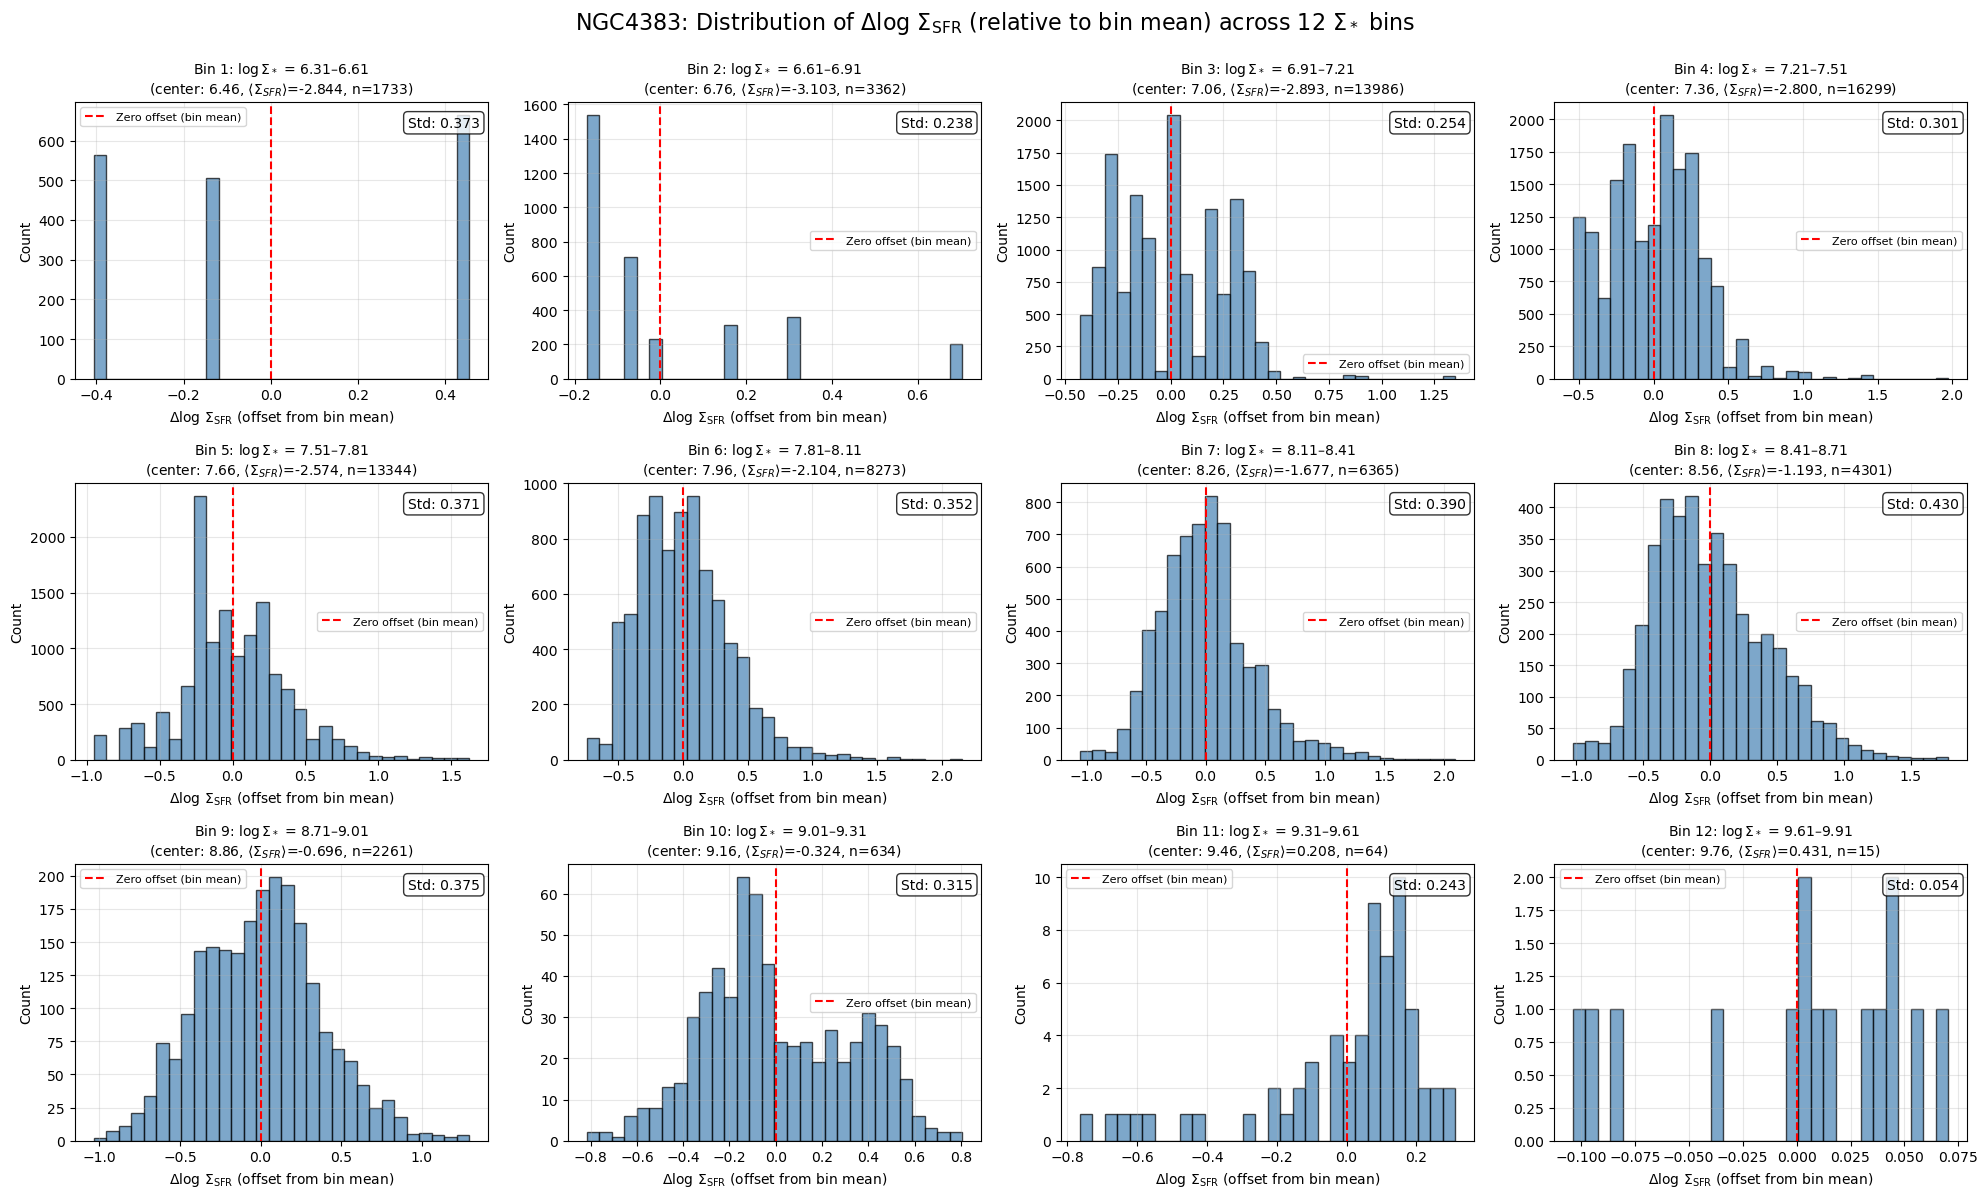


NGC4383: Σ_SFR offset statistics by Σ* bin (offset = Σ_SFR - mean(Σ_SFR in bin)):
Bin   Σ* range             n pixels   bin mean Σ_SFR       std offset     
-------------------------------------------------------------------------------------
1     6.31–6.61     1733       -2.844               0.373          
2     6.61–6.91     3362       -3.103               0.238          
3     6.91–7.21     13986      -2.893               0.254          
4     7.21–7.51     16299      -2.800               0.301          
5     7.51–7.81     13344      -2.574               0.371          
6     7.81–8.11     8273       -2.104               0.352          
7     8.11–8.41     6365       -1.677               0.390          
8     8.41–8.71     4301       -1.193               0.430          
9     8.71–9.01     2261       -0.696               0.375          
10    9.01–9.31     634        -0.324               0.315          
11    9.31–9.61     64         0.208                0.243          
12    9.

In [8]:
# ------------------------------------------------------------------
# Plot histogram of Σ_SFR offset for all 12 Σ* bins
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt

# Only focus on NGC4383 for this visualisation
galaxies = ['NGC4383']

# ------------------------------------------------------------------
# 1.  Helper: read the required maps
# ------------------------------------------------------------------
def load_maps(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_O3N2_M14_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M14_HII'].data
            indicator_name = 'O3N2-M14'
        elif 'O_H_O3N2_M13_HII' in h_gas:
            print(f"Warning: O3N2-M14 not available for {gal}; using O3N2-M13 instead.")
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
            indicator_name = 'O3N2-M13'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No O3N2 metallicity extension (M14/M13) found for {gal}. Available: {available}")
    return sigM, sigSFR, oh_map, indicator_name

for gal in galaxies:
    sigM, sigSFR, oh_o3n2_map, indicator_name = load_maps(gal)

    # Valid pixels across maps
    valid_sfr = np.isfinite(sigSFR)
    valid_oh = np.isfinite(oh_o3n2_map)
    valid_sigM = np.isfinite(sigM)
    valid_all = valid_sfr & valid_oh & valid_sigM

    # ------------------------------------------------------------------
    # 2.  Define 12 Σ* bins
    # ------------------------------------------------------------------
    n_bins = 12
    sigmaM_min = np.nanmin(sigM[valid_all])
    sigmaM_max = np.nanmax(sigM[valid_all])
    sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)
    
    # ------------------------------------------------------------------
    # 3.  Create histogram for each bin (offset calculated per bin)
    # ------------------------------------------------------------------
    fig, axes = plt.subplots(3, 4, figsize=(20, 12))
    axes = axes.flatten()
    
    for i in range(n_bins):
        # Define bin mask
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        
        # Get Σ_SFR values in this bin
        sfr_bin = sigSFR[bin_mask]
        
        # Calculate offset WITHIN this bin (relative to bin mean)
        sfr_bin_mean = np.mean(sfr_bin)
        sfr_offset_bin = sfr_bin - sfr_bin_mean
        
        # Plot histogram
        axes[i].hist(sfr_offset_bin, bins=30, color='steelblue', alpha=0.7, edgecolor='black')
        
        # Add vertical line at 0 (which is now the mean by definition)
        axes[i].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero offset (bin mean)')
        
        # Add statistics
        std_offset = np.std(sfr_offset_bin)
        axes[i].text(0.98, 0.95, f'Std: {std_offset:.3f}', transform=axes[i].transAxes,
                    fontsize=10, verticalalignment='top', horizontalalignment='right',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        # Set title with bin range
        bin_center = (sigmaM_bin_edges[i] + sigmaM_bin_edges[i+1]) / 2
        axes[i].set_title(f'Bin {i+1}: $\\log\\Sigma_*$ = {sigmaM_bin_edges[i]:.2f}–{sigmaM_bin_edges[i+1]:.2f}\n'
                         f'(center: {bin_center:.2f}, $\\langle\\Sigma_{{{{SFR}}}}\\rangle$={sfr_bin_mean:.3f}, n={np.sum(bin_mask)})', 
                         fontsize=10)
        axes[i].set_xlabel(r'$\Delta\log\,\Sigma_{\mathrm{SFR}}$ (offset from bin mean)', fontsize=10)
        axes[i].set_ylabel('Count', fontsize=10)
        axes[i].legend(fontsize=8)
        axes[i].grid(True, alpha=0.3)
    
    plt.suptitle(rf'{gal}: Distribution of $\Delta\log\,\Sigma_{{\mathrm{{SFR}}}}$ (relative to bin mean) across 12 $\Sigma_*$ bins', 
                 fontsize=16, y=0.995)
    plt.tight_layout()
    # plt.savefig(f'{gal}_SigmaSFR_offset_histogram_by_SigmaM_bins.png', dpi=600, bbox_inches='tight')
    # plt.savefig(f'{gal}_SigmaSFR_offset_histogram_by_SigmaM_bins.pdf', bbox_inches='tight')
    plt.show()
    
    # Print summary statistics
    print(f"\n{gal}: Σ_SFR offset statistics by Σ* bin (offset = Σ_SFR - mean(Σ_SFR in bin)):")
    print(f"{'Bin':<5} {'Σ* range':<20} {'n pixels':<10} {'bin mean Σ_SFR':<20} {'std offset':<15}")
    print("-" * 85)
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        
        sfr_bin = sigSFR[bin_mask]
        sfr_bin_mean = np.mean(sfr_bin)
        sfr_offset_bin = sfr_bin - sfr_bin_mean
        std_offset = np.std(sfr_offset_bin)
        
        print(f"{i+1:<5} {sigmaM_bin_edges[i]:.2f}–{sigmaM_bin_edges[i+1]:.2f}     "
              f"{np.sum(bin_mask):<10} {sfr_bin_mean:<20.3f} {std_offset:<15.3f}")


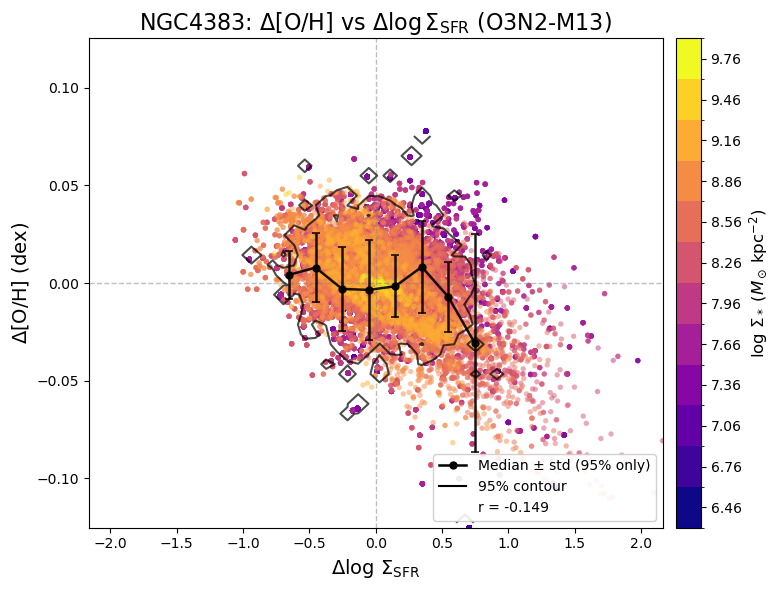


NGC4383: Single offset relation plot complete!
  Number of Σ* bins: 12
  Σ* range: 6.315 to 9.905
  Total points used: 70637
  Pearson r: -0.149, p = 0.000e+00


In [9]:
# -------------------------------------------------------------
# 9. Offset relation: Δ[O/H] vs Δlog(Σ_SFR) for 12 Σ* bins
#    - Single combined scatter plot with points coloured by Σ* bin
#    - Median trend (95% only) with std error bars
#    - 95% population contour
#    - Pearson correlation in legend
# -------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
from scipy.stats import pearsonr
from matplotlib.lines import Line2D

# Helper: load maps (no WCS needed here)
def load_maps(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_O3N2_M14_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M14_HII'].data
            indicator_name = 'O3N2-M14'
        elif 'O_H_O3N2_M13_HII' in h_gas:
            print(f"Warning: O3N2-M14 not available for {gal}; using O3N2-M13 instead.")
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
            indicator_name = 'O3N2-M13'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No O3N2 metallicity extension (M14/M13) found for {gal}. Available: {available}")
    return sigM, sigSFR, oh_map, indicator_name

# Helper: calculate binned statistics with unique-count requirement
def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_unique=20):
    """Calculate median and std in x-bins.

    Only keep bins where there are at least `min_unique` unique y-data
    points within the bin. Returns bin centers, medians, stds, and counts.
    """
    x_data = np.asarray(x_data)
    y_data = np.asarray(y_data)

    finite = np.isfinite(x_data) & np.isfinite(y_data)
    if np.sum(finite) == 0:
        return np.array([]), np.array([]), np.array([]), np.array([])

    x_min, x_max = np.nanmin(x_data[finite]), np.nanmax(x_data[finite])
    if not np.isfinite(x_min) or not np.isfinite(x_max) or x_min == x_max:
        return np.array([]), np.array([]), np.array([]), np.array([])

    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    if bin_edges.size < 2:
        return np.array([]), np.array([]), np.array([]), np.array([])

    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    medians = []
    stds = []
    counts = []
    valid_centers = []

    for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        in_bin = finite & (x_data >= bin_start) & (x_data < bin_end)
        if np.sum(in_bin) == 0:
            continue

        y_in_bin = y_data[in_bin]
        # Require sufficient unique y values in this bin
        if len(np.unique(y_in_bin)) >= min_unique:
            medians.append(np.nanmedian(y_in_bin))
            stds.append(np.nanstd(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(bin_centers[i])

    return (np.array(valid_centers), np.array(medians),
            np.array(stds), np.array(counts))

# Only focus on NGC4383 for this visualisation
galaxies = ['NGC4383']

for gal in galaxies:
    sigM, sigSFR, oh_o3n2_map, indicator_name = load_maps(gal)

    valid_sfr = np.isfinite(sigSFR)
    valid_oh = np.isfinite(oh_o3n2_map)
    valid_sigM = np.isfinite(sigM)
    valid_all = valid_sfr & valid_oh & valid_sigM

    # Define 12 Σ* bins
    n_bins = 12
    sigmaM_min = np.nanmin(sigM[valid_all])
    sigmaM_max = np.nanmax(sigM[valid_all])
    sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)
    bin_centers = [(sigmaM_bin_edges[i] + sigmaM_bin_edges[i+1]) / 2 for i in range(n_bins)]

    # Discrete colormap for Σ* bins
    cmap_discrete = plt.cm.plasma
    norm_discrete = BoundaryNorm(sigmaM_bin_edges, cmap_discrete.N)

    # Collect all offsets across bins
    all_delta_sfr = []
    all_delta_oh = []
    all_bin_colors = []

    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all

        if np.sum(bin_mask) == 0:
            continue

        sfr_bin = sigSFR[bin_mask]
        oh_bin = oh_o3n2_map[bin_mask]

        sfr_offset_bin = sfr_bin - np.mean(sfr_bin)
        oh_offset_bin = oh_bin - np.mean(oh_bin)

        all_delta_sfr.extend(sfr_offset_bin)
        all_delta_oh.extend(oh_offset_bin)

        bin_color = cmap_discrete(norm_discrete(bin_centers[i]))
        all_bin_colors.extend([bin_color] * len(sfr_offset_bin))

    all_delta_sfr = np.array(all_delta_sfr)
    all_delta_oh = np.array(all_delta_oh)
    all_bin_colors = np.array(all_bin_colors)

    valid_corr = np.isfinite(all_delta_sfr) & np.isfinite(all_delta_oh)

    # Pearson correlation
    if np.sum(valid_corr) > 2:
        pearson_r, pearson_p = pearsonr(all_delta_sfr[valid_corr], all_delta_oh[valid_corr])
    else:
        pearson_r, pearson_p = np.nan, np.nan

    # Figure
    fig, ax = plt.subplots(figsize=(8, 6))

    # Scatter: coloured by Σ* bin
    scatter = ax.scatter(all_delta_sfr[valid_corr], all_delta_oh[valid_corr],
                         c=all_bin_colors[valid_corr], s=15, alpha=0.5,
                         edgecolors='none', rasterized=True)

    # Zero reference lines
    ax.axhline(0, color='gray', linestyle='--', linewidth=1.0, alpha=0.5)
    ax.axvline(0, color='gray', linestyle='--', linewidth=1.0, alpha=0.5)

    # Axis labels
    ax.set_xlabel(r'$\Delta\log\,\Sigma_{\mathrm{SFR}}$', fontsize=14)
    ax.set_ylabel(r'$\Delta$[O/H] (dex)', fontsize=14)

    # Symmetric limits
    max_abs_sfr = np.nanmax(np.abs(all_delta_sfr[valid_corr]))
    max_abs_oh = np.nanmax(np.abs(all_delta_oh[valid_corr]))
    ax.set_xlim(-max_abs_sfr, max_abs_sfr)
    ax.set_ylim(-max_abs_oh, max_abs_oh)

    # ------------------------------------------------------------------
    # 95% contour and mask
    # ------------------------------------------------------------------
    contour_mask = np.zeros_like(valid_corr, dtype=bool)
    if np.sum(valid_corr) > 20:
        try:
            H, xedges, yedges = np.histogram2d(all_delta_sfr[valid_corr], all_delta_oh[valid_corr],
                                               bins=40, density=True)
            H_flat = H.flatten()
            H_sorted = np.sort(H_flat)[::-1]
            H_cumsum = np.cumsum(H_sorted)
            H_cumsum /= H_cumsum[-1]
            threshold_95 = H_sorted[np.where(H_cumsum >= 0.95)[0][0]]

            x_centers = (xedges[:-1] + xedges[1:]) / 2
            y_centers = (yedges[:-1] + yedges[1:]) / 2

            x_idx = np.searchsorted(xedges, all_delta_sfr[valid_corr], side='right') - 1
            y_idx = np.searchsorted(yedges, all_delta_oh[valid_corr], side='right') - 1

            x_idx = np.clip(x_idx, 0, H.shape[0]-1)
            y_idx = np.clip(y_idx, 0, H.shape[1]-1)

            inside = H[x_idx, y_idx] >= threshold_95
            contour_mask[valid_corr] = inside

            X, Y = np.meshgrid(x_centers, y_centers)
            ax.contour(X, Y, H.T, levels=[threshold_95], colors='black',
                       linewidths=1.5, linestyles='solid', alpha=0.7)
        except Exception:
            contour_mask[:] = True
    else:
        contour_mask[:] = True

    # ------------------------------------------------------------------
    # Median trend using only points inside 95% contour
    # and requiring at least `min_unique` unique y per bin
    # ------------------------------------------------------------------
    x_trend = all_delta_sfr[contour_mask]
    y_trend = all_delta_oh[contour_mask]

    centers, medians, stds, counts = calculate_binned_stats(x_trend, y_trend,
                                                            bin_width=0.2,
                                                            min_unique=20)

    if centers.size > 0:
        ax.errorbar(centers, medians, yerr=stds,
                    color='black', linewidth=1.8, marker='o', markersize=5,
                    capsize=3, capthick=1.2, zorder=10, alpha=0.9,
                    label='Median ± std (95% only)')

    # Colorbar for Σ* bins
    sm = plt.cm.ScalarMappable(cmap=cmap_discrete, norm=norm_discrete)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, pad=0.02)
    cbar.set_label(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
    cbar.set_ticks(bin_centers)
    cbar.set_ticklabels([f'{bc:.2f}' for bc in bin_centers])

    # Legend: median trend, 95% contour, Pearson r
    legend_elements = []
    if centers.size > 0:
        legend_elements.append(Line2D([0], [0], color='black', linewidth=1.8,
                                      marker='o', markersize=5,
                                      label='Median ± std (95% only)'))
    legend_elements.append(Line2D([0], [0], color='black', linewidth=1.5,
                                  linestyle='solid', label='95% contour'))
    legend_elements.append(Line2D([0], [0], color='none',
                                  label=f'r = {pearson_r:.3f}'))

    ax.legend(handles=legend_elements, loc='lower right', fontsize=10,
              framealpha=0.9)

    ax.set_title(rf'{gal}: Δ[O/H] vs Δ$\log\Sigma_{{\mathrm{{SFR}}}}$ ({indicator_name})',
                 fontsize=16)

    plt.tight_layout()
    plt.show()

    print(f"\n{gal}: Single offset relation plot complete!")
    print(f"  Number of Σ* bins: {n_bins}")
    print(f"  Σ* range: {sigmaM_min:.3f} to {sigmaM_max:.3f}")
    print(f"  Total points used: {np.sum(valid_corr)}")
    print(f"  Pearson r: {pearson_r:.3f}, p = {pearson_p:.3e}")


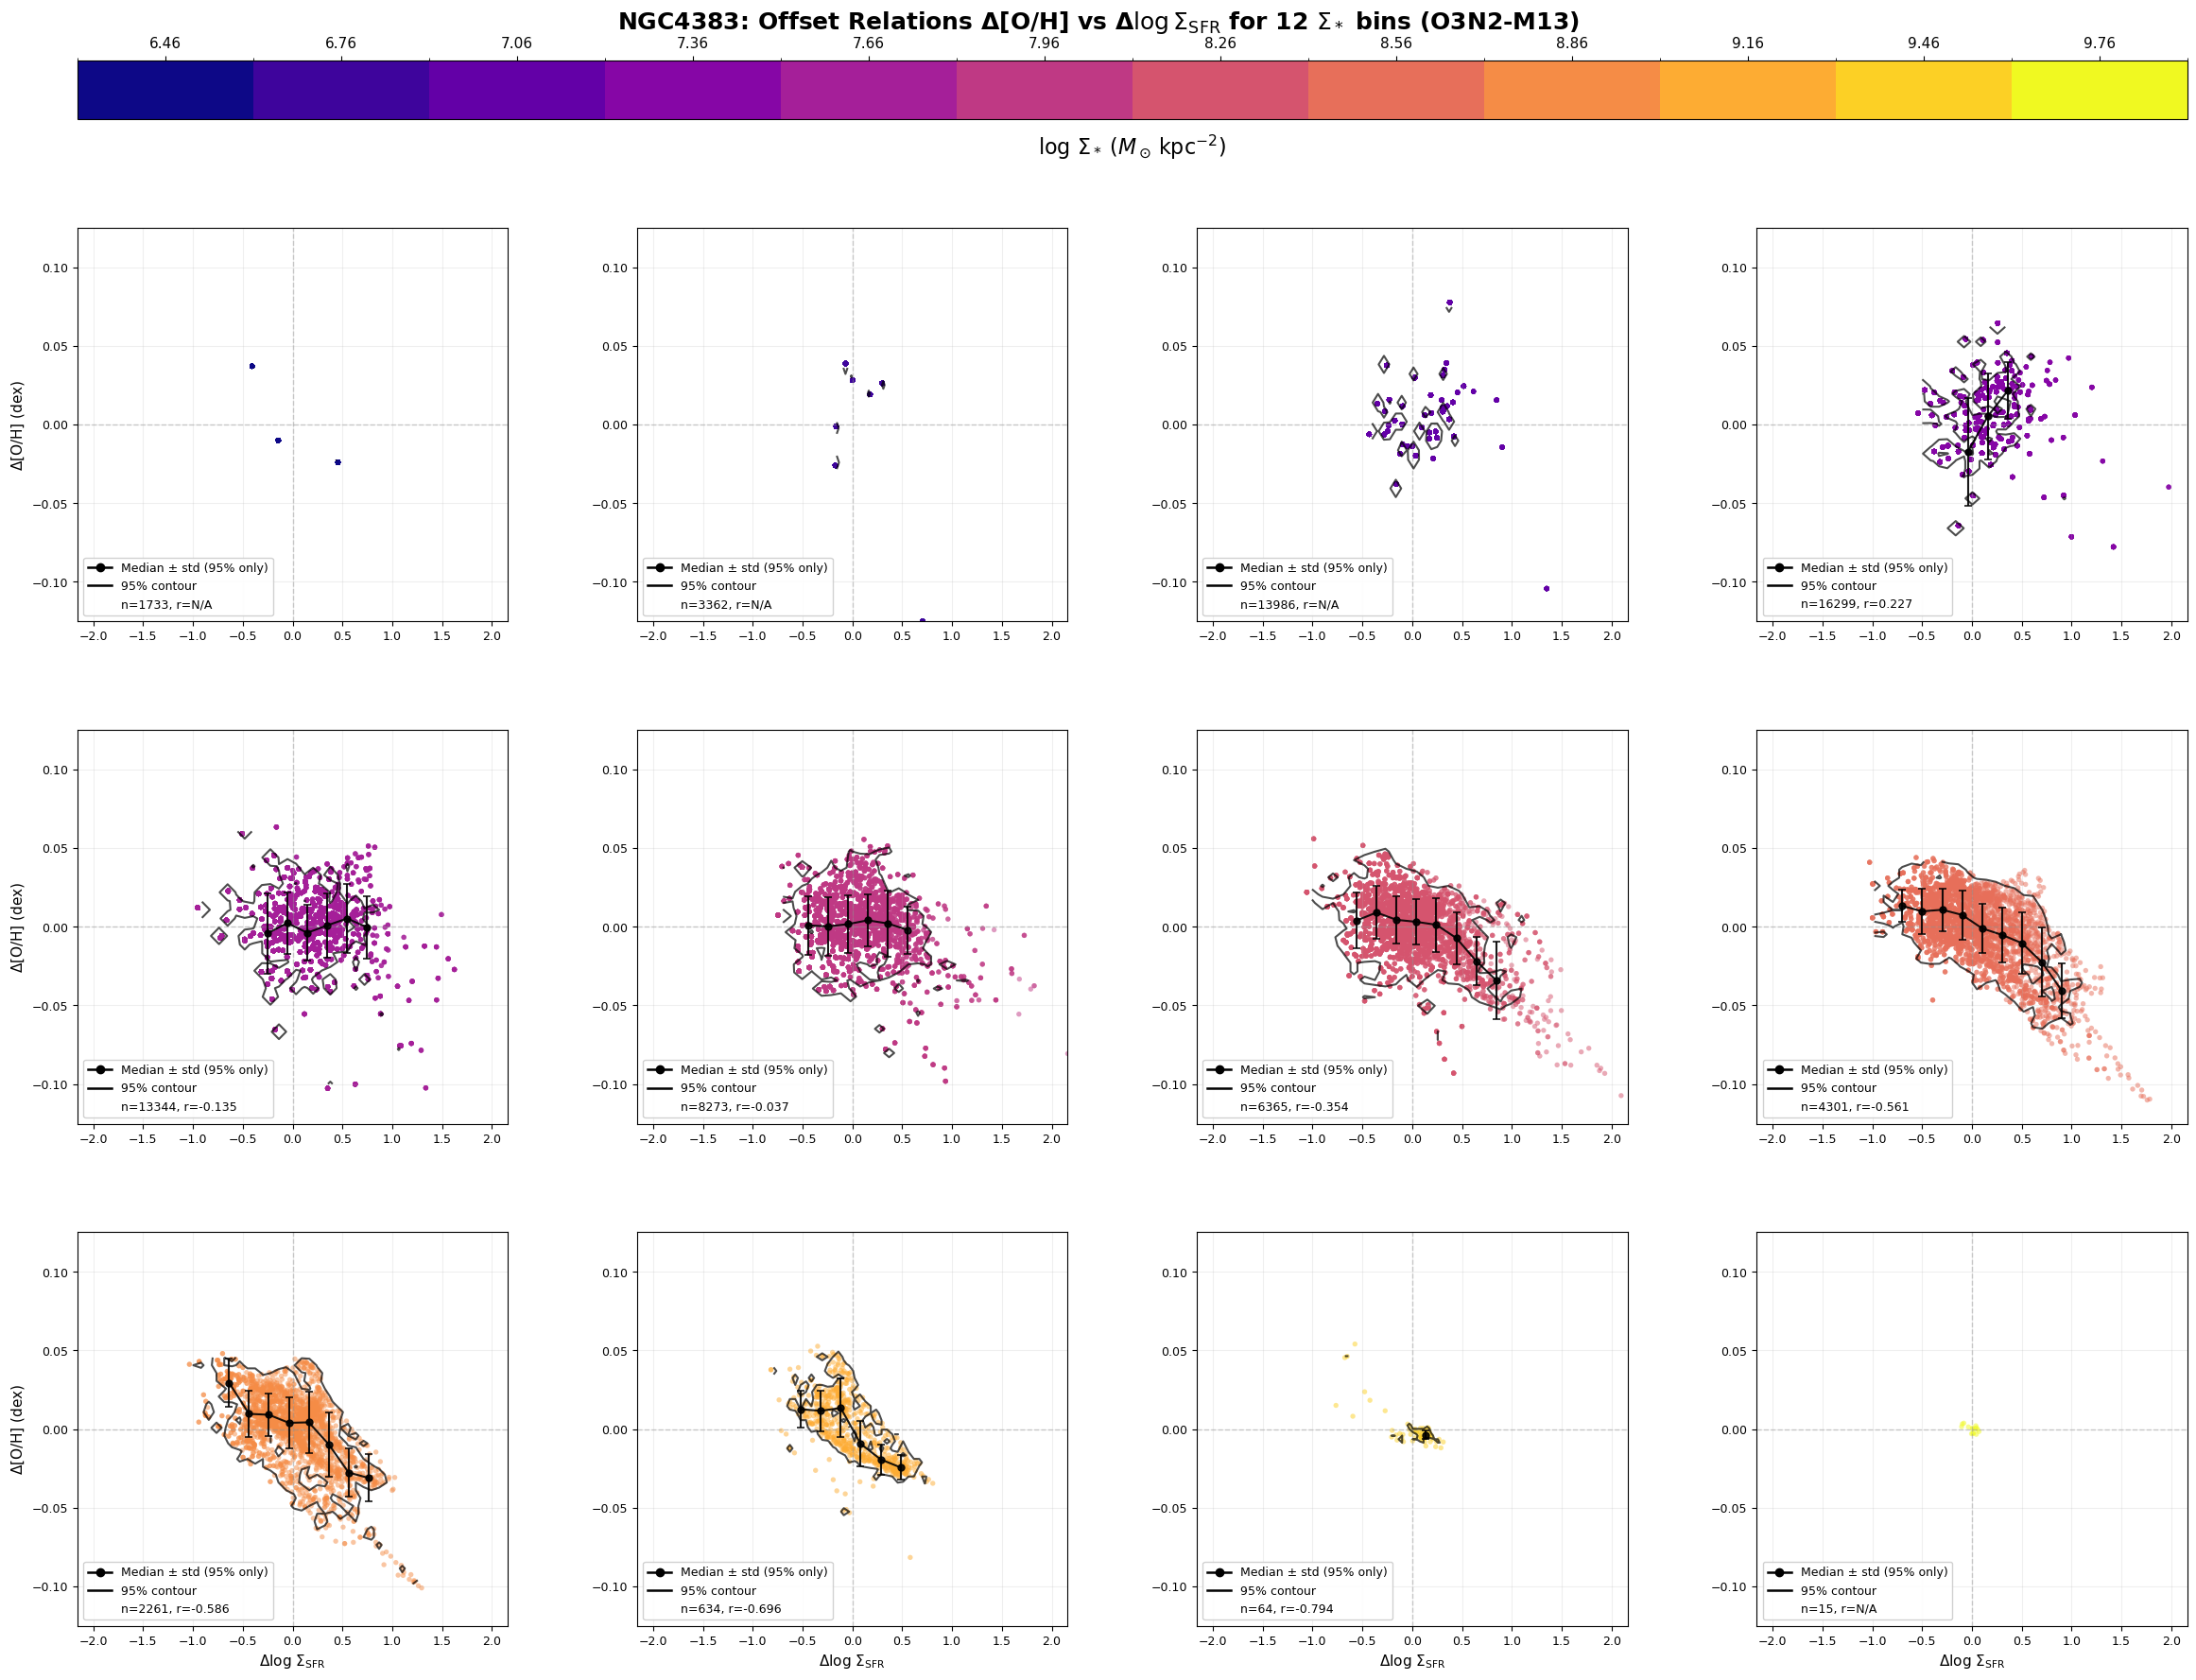


NGC4383: 12-panel offset relation grid complete!
  Number of Σ* bins: 12
  Σ* range: 6.315 to 9.905
  Global Δlog(Σ_SFR) axis limits: ±2.161
  Global Δ[O/H] axis limits: ±0.125


In [10]:
# ------------------------------------------------------------------
# Plot 12 separate offset relations (one per Σ* bin) in 3x4 grid
# With shared colorbar at the top
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
import matplotlib.gridspec as gridspec
from scipy.stats import pearsonr
from matplotlib.lines import Line2D

# ------------------------------------------------------------------
# Helper: read the required maps
# ------------------------------------------------------------------
def load_maps(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_O3N2_M14_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M14_HII'].data
            indicator_name = 'O3N2-M14'
        elif 'O_H_O3N2_M13_HII' in h_gas:
            print(f"Warning: O3N2-M14 not available for {gal}; using O3N2-M13 instead.")
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
            indicator_name = 'O3N2-M13'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No O3N2 metallicity extension (M14/M13) found for {gal}. Available: {available}")
    return sigM, sigSFR, oh_map, indicator_name

# ------------------------------------------------------------------
# Helper: calculate binned statistics with unique-count requirement
# ------------------------------------------------------------------
def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_unique=20):
    """Calculate median and std in x-bins.

    Only keep bins where there are at least `min_unique` unique y-data
    points within the bin. Returns bin centers, medians, stds, and counts.
    """
    x_data = np.asarray(x_data)
    y_data = np.asarray(y_data)

    finite = np.isfinite(x_data) & np.isfinite(y_data)
    if np.sum(finite) == 0:
        return np.array([]), np.array([]), np.array([]), np.array([])

    x_min, x_max = np.nanmin(x_data[finite]), np.nanmax(x_data[finite])
    if not np.isfinite(x_min) or not np.isfinite(x_max) or x_min == x_max:
        return np.array([]), np.array([]), np.array([]), np.array([])

    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    if bin_edges.size < 2:
        return np.array([]), np.array([]), np.array([]), np.array([])

    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    medians = []
    stds = []
    counts = []
    valid_centers = []

    for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        in_bin = finite & (x_data >= bin_start) & (x_data < bin_end)
        if np.sum(in_bin) == 0:
            continue

        y_in_bin = y_data[in_bin]
        # Require sufficient unique y values in this bin
        if len(np.unique(y_in_bin)) >= min_unique:
            medians.append(np.nanmedian(y_in_bin))
            stds.append(np.nanstd(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(bin_centers[i])

    return (np.array(valid_centers), np.array(medians),
            np.array(stds), np.array(counts))

# Only focus on NGC4383 for this visualisation
galaxies = ['NGC4383']

for gal in galaxies:
    sigM, sigSFR, oh_o3n2_map, indicator_name = load_maps(gal)

    # Valid pixels across maps
    valid_sfr = np.isfinite(sigSFR)
    valid_oh = np.isfinite(oh_o3n2_map)
    valid_sigM = np.isfinite(sigM)
    valid_all = valid_sfr & valid_oh & valid_sigM

    # ------------------------------------------------------------------
    # 1.  Define 12 Σ* bins
    # ------------------------------------------------------------------
    n_bins = 12
    sigmaM_min = np.nanmin(sigM[valid_all])
    sigmaM_max = np.nanmax(sigM[valid_all])
    sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)
    
    # Calculate bin centers for color mapping
    bin_centers = [(sigmaM_bin_edges[i] + sigmaM_bin_edges[i+1]) / 2 for i in range(n_bins)]
    
    # Use same discrete colormap as bottom-right panel in cell 8
    cmap_discrete = plt.cm.plasma
    norm_discrete = BoundaryNorm(sigmaM_bin_edges, cmap_discrete.N)
    
    # ------------------------------------------------------------------
    # 2.  Calculate global axis limits (same for all subplots)
    # ------------------------------------------------------------------
    global_max_abs_sfr = 0
    global_max_abs_oh = 0
    
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        
        if np.sum(bin_mask) > 0:
            sfr_bin = sigSFR[bin_mask]
            oh_bin = oh_o3n2_map[bin_mask]
            
            sfr_offset = sfr_bin - np.mean(sfr_bin)
            oh_offset = oh_bin - np.mean(oh_bin)
            
            global_max_abs_sfr = max(global_max_abs_sfr, np.nanmax(np.abs(sfr_offset)))
            global_max_abs_oh = max(global_max_abs_oh, np.nanmax(np.abs(oh_offset)))
    
    # ------------------------------------------------------------------
    # 3.  Create 3x4 subplot grid with colorbar at top
    # ------------------------------------------------------------------
    fig = plt.figure(figsize=(24, 18))
    
    # Create grid: 1 row for colorbar, 3 rows for subplots
    gs = gridspec.GridSpec(4, 4, figure=fig, 
                          height_ratios=[0.15, 1, 1, 1],
                          hspace=0.35, wspace=0.3,
                          top=0.96, bottom=0.04, left=0.05, right=0.98)
    
    # Create colorbar axis at the top (spanning all columns)
    cbar_ax = fig.add_subplot(gs[0, :])
    
    # Create 12 subplots in 3x4 grid
    axes = []
    for row in range(3):
        for col in range(4):
            ax = fig.add_subplot(gs[row + 1, col])
            axes.append(ax)
    
    # ------------------------------------------------------------------
    # 4.  Plot each Σ* bin in its own subplot
    # ------------------------------------------------------------------
    for i in range(n_bins):
        ax = axes[i]
        
        # Define bin mask
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        
        n_pixels = np.sum(bin_mask)
        
        if n_pixels > 0:
            # Get values in this bin
            sfr_bin = sigSFR[bin_mask]
            oh_bin = oh_o3n2_map[bin_mask]
            
            # Calculate offsets WITHIN this bin
            sfr_bin_mean = np.mean(sfr_bin)
            oh_bin_mean = np.mean(oh_bin)
            
            sfr_offset = sfr_bin - sfr_bin_mean
            oh_offset = oh_bin - oh_bin_mean
            
            # Validity mask in this bin
            valid_corr = np.isfinite(sfr_offset) & np.isfinite(oh_offset)
            
            # Get color for this bin
            bin_color = cmap_discrete(norm_discrete(bin_centers[i]))
            
            # Scatter plot (all valid points in bin)
            ax.scatter(sfr_offset[valid_corr], oh_offset[valid_corr], 
                      c=[bin_color], s=15, alpha=0.5, edgecolors='none', rasterized=True)
            
            # ------------------------------------------------------------------
            # Calculate 95% contour and mask
            # ------------------------------------------------------------------
            contour_mask = np.zeros_like(valid_corr, dtype=bool)
            if np.sum(valid_corr) > 20:
                try:
                    H, xedges, yedges = np.histogram2d(sfr_offset[valid_corr], oh_offset[valid_corr],
                                                       bins=30, density=True)
                    H_flat = H.flatten()
                    H_sorted = np.sort(H_flat)[::-1]
                    H_cumsum = np.cumsum(H_sorted)
                    H_cumsum /= H_cumsum[-1]
                    threshold_95 = H_sorted[np.where(H_cumsum >= 0.95)[0][0]]

                    x_centers = (xedges[:-1] + xedges[1:]) / 2
                    y_centers = (yedges[:-1] + yedges[1:]) / 2

                    x_idx = np.searchsorted(xedges, sfr_offset[valid_corr], side='right') - 1
                    y_idx = np.searchsorted(yedges, oh_offset[valid_corr], side='right') - 1

                    x_idx = np.clip(x_idx, 0, H.shape[0]-1)
                    y_idx = np.clip(y_idx, 0, H.shape[1]-1)

                    inside = H[x_idx, y_idx] >= threshold_95
                    contour_mask[valid_corr] = inside

                    X, Y = np.meshgrid(x_centers, y_centers)
                    ax.contour(X, Y, H.T, levels=[threshold_95], colors='black',
                              linewidths=1.5, linestyles='solid', alpha=0.7)
                except Exception:
                    contour_mask[:] = True
            else:
                contour_mask[:] = True
            
            # ------------------------------------------------------------------
            # Calculate median trend using only points inside 95% contour
            # and requiring at least `min_unique` unique y-values per bin
            # ------------------------------------------------------------------
            x_trend = sfr_offset[contour_mask]
            y_trend = oh_offset[contour_mask]

            centers, medians, stds, counts = calculate_binned_stats(x_trend, y_trend,
                                                                    bin_width=0.2,
                                                                    min_unique=20)

            has_trend = centers.size > 0
            if has_trend:
                ax.errorbar(centers, medians, yerr=stds,
                           color='black', linewidth=1.5, marker='o', markersize=5,
                           capsize=3, capthick=1.2, zorder=10, alpha=0.9)
            
            # ------------------------------------------------------------------
            # Pearson r: only for points inside 95% contour and only if trend exists
            # ------------------------------------------------------------------
            if has_trend and np.sum(contour_mask & valid_corr) > 2:
                pearson_r, pearson_p = pearsonr(sfr_offset[contour_mask & valid_corr],
                                                oh_offset[contour_mask & valid_corr])
                r_label = f'r={pearson_r:.3f}'
            else:
                pearson_r, pearson_p = np.nan, np.nan
                r_label = 'r=N/A'
            
            # Add zero reference lines
            ax.axhline(0, color='gray', linestyle='--', linewidth=1.0, alpha=0.4, zorder=1)
            ax.axvline(0, color='gray', linestyle='--', linewidth=1.0, alpha=0.4, zorder=1)
            
            # Set symmetric limits (global)
            ax.set_xlim(-global_max_abs_sfr, global_max_abs_sfr)
            ax.set_ylim(-global_max_abs_oh, global_max_abs_oh)
            
            # Grid
            ax.grid(True, alpha=0.2)
            
            # Legend entries for each subplot: median, contour, n and r
            legend_elements = [
                Line2D([0], [0], color='black', linewidth=1.8, marker='o', markersize=6,
                       label='Median ± std (95% only)'),
                Line2D([0], [0], color='black', linewidth=1.8, linestyle='solid',
                       label='95% contour'),
                Line2D([0], [0], color='none',
                       label=f'n={n_pixels}, {r_label}')
            ]
            ax.legend(handles=legend_elements, loc='lower left', fontsize=9,
                      framealpha=0.9)
            
            # Labels (only on left and bottom edges)
            if i % 4 == 0:  # Left column
                ax.set_ylabel(r'$\Delta$[O/H] (dex)', fontsize=11)
            if i >= 8:  # Bottom row
                ax.set_xlabel(r'$\Delta\log\,\Sigma_{\mathrm{SFR}}$', fontsize=11)
            
            ax.tick_params(labelsize=9)
        else:
            # No data in this bin
            ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                   transform=ax.transAxes, fontsize=12, color='gray')
            ax.set_xticks([])
            ax.set_yticks([])
    
    # ------------------------------------------------------------------
    # 5.  Create horizontal colorbar at the top
    # ------------------------------------------------------------------
    sm = plt.cm.ScalarMappable(cmap=cmap_discrete, norm=norm_discrete)
    sm.set_array([])
    
    cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
    cbar.set_label(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=16, labelpad=10)
    cbar.set_ticks(bin_centers)
    cbar.set_ticklabels([f'{bc:.2f}' for bc in bin_centers], fontsize=11)
    cbar_ax.xaxis.set_ticks_position('top')
    cbar_ax.xaxis.set_label_position('bottom')
    
    fig.suptitle(rf'{gal}: Offset Relations Δ[O/H] vs Δ$\log\Sigma_{{\mathrm{{SFR}}}}$ for 12 $\Sigma_*$ bins ({indicator_name})',
                fontsize=18, y=0.99, fontweight='bold')
    
    plt.show()
    
    print(f"\n{gal}: 12-panel offset relation grid complete!")
    print(f"  Number of Σ* bins: {n_bins}")
    print(f"  Σ* range: {sigmaM_min:.3f} to {sigmaM_max:.3f}")
    print(f"  Global Δlog(Σ_SFR) axis limits: ±{global_max_abs_sfr:.3f}")
    print(f"  Global Δ[O/H] axis limits: ±{global_max_abs_oh:.3f}")


/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_32329/4171854040.py:353: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


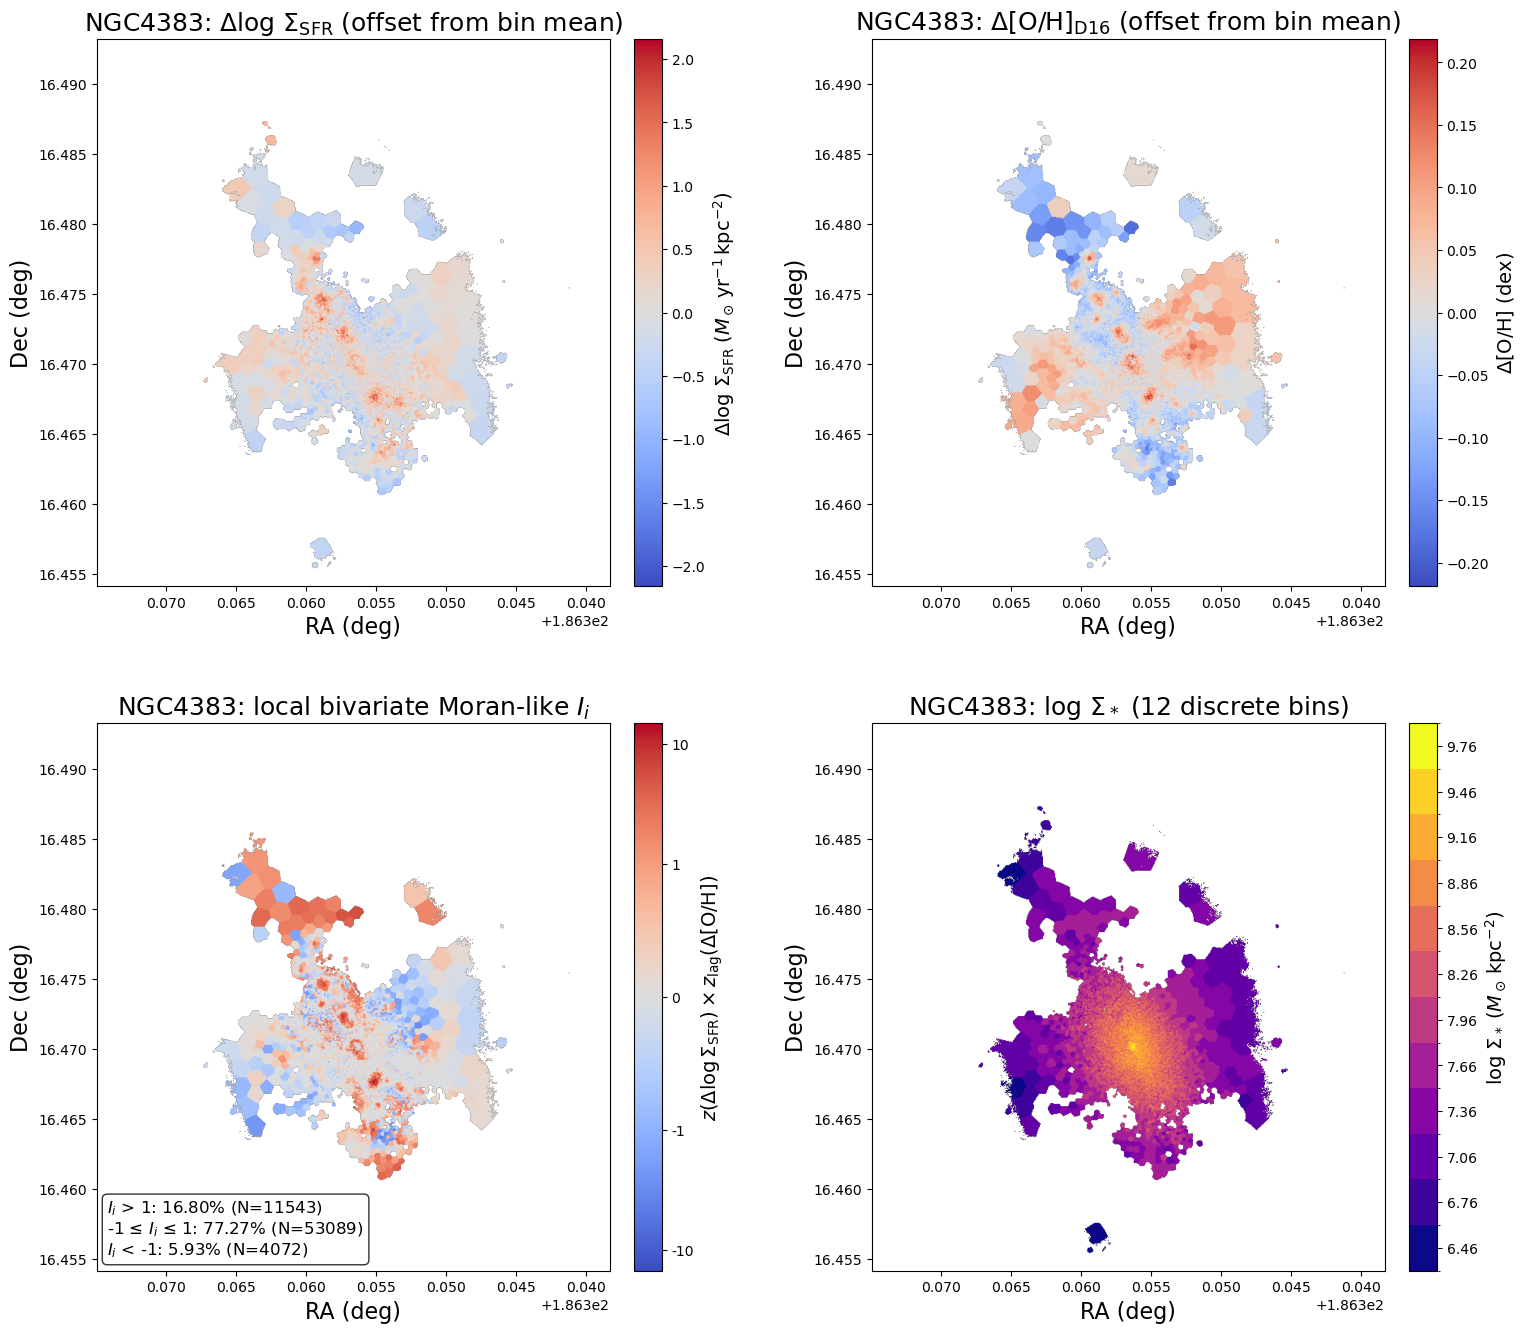


2x2 combined figure complete for NGC4383!
  Σ_SFR offset range: -2.161 to 2.161
  [O/H] offset range: -0.219 to 0.219
  Moran I_i range: -3.690 to 14.881
  Σ* bins: 12 bins from 6.315 to 9.905
  I_i > 1: 16.80% (N=11543)
  -1 ≤ I_i ≤ 1: 77.27% (N=53089)
  I_i < -1: 5.93% (N=4072)


In [11]:
# ------------------------------------------------------------------
# 2x2 Combined figure: offset maps + Moran-like map + binned Σ* map
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gs_module
from matplotlib.colors import BoundaryNorm, SymLogNorm

# Only focus on NGC4383 for this visualisation
galaxies = ['NGC4383']

# ------------------------------------------------------------------
# Define threshold parameter for linear/log colorbar transition and classification
# ------------------------------------------------------------------
threshold = 1  # Values between -threshold and +threshold use linear scale

# ------------------------------------------------------------------
# 1.  Helper: read the required maps
# ------------------------------------------------------------------
def load_maps(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
        binid_map = h_spatial['BINID'].data
        wcs = WCS(h_spatial['LOGMASS_SURFACE_DENSITY'].header)
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_D16_HII' in h_gas:
            oh_map = h_gas['O_H_D16_HII'].data
            indicator_name = 'D16'
        elif 'O_H_O3N2_M14_HII' in h_gas:
            print(f"Warning: D16 not available for {gal}; using O3N2-M14 instead.")
            oh_map = h_gas['O_H_O3N2_M14_HII'].data
            indicator_name = 'O3N2-M14'
        elif 'O_H_O3N2_M13_HII' in h_gas:
            print(f"Warning: D16 and O3N2-M14 not available for {gal}; using O3N2-M13 instead.")
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
            indicator_name = 'O3N2-M13'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No metallicity extension (D16/O3N2-M14/O3N2-M13) found for {gal}. Available: {available}")
        gas_header = h_gas['LOGSFR_SURFACE_DENSITY_HII'].header
    return sigM, sigSFR, oh_map, indicator_name, wcs, gas_header, binid_map

for gal in galaxies:
    sigM, sigSFR, oh_o3n2_map, indicator_name, wcs_full, gas_header, binid_map = load_maps(gal)
    # Valid pixels across maps
    valid_sfr = np.isfinite(sigSFR)
    valid_oh = np.isfinite(oh_o3n2_map)
    valid_sigM = np.isfinite(sigM)
    valid_all = valid_sfr & valid_oh & valid_sigM

    # ------------------------------------------------------------------
    # 2.  Calculate offset maps (relative to Σ* bin means)
    # ------------------------------------------------------------------
    # Define 12 Σ* bins
    n_bins = 12
    sigmaM_min = np.nanmin(sigM[valid_all])
    sigmaM_max = np.nanmax(sigM[valid_all])
    sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)
    
    # Initialize offset maps
    sfr_offset = np.full_like(sigSFR, np.nan)
    oh_offset = np.full_like(oh_o3n2_map, np.nan)
    
    # Calculate offset for each Σ* bin
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        
        if np.sum(bin_mask) > 0:
            # Calculate bin mean and offset within this bin
            sfr_bin_mean = np.mean(sigSFR[bin_mask])
            oh_bin_mean = np.mean(oh_o3n2_map[bin_mask])
            
            sfr_offset[bin_mask] = sigSFR[bin_mask] - sfr_bin_mean
            oh_offset[bin_mask] = oh_o3n2_map[bin_mask] - oh_bin_mean
    
    sfr_offset_max = np.nanmax(np.abs(sfr_offset[valid_all]))
    oh_offset_max = np.nanmax(np.abs(oh_offset[valid_all]))
    
    # Global means for display purposes only
    sfr_mean = np.nanmean(sigSFR[valid_sfr])
    oh_mean = np.nanmean(oh_o3n2_map[valid_oh])

    # ------------------------------------------------------------------
    # 3.  Calculate local bivariate Moran-like map
    # ------------------------------------------------------------------
    def local_bivariate_moran_by_bin(A, B, valid_mask, binid_map, neighbourhood='queen'):
        """Local bivariate Moran-style statistic on adjacent spatial bins.

        Each valid BINID is treated as one graph node, using the mean A and B value
        of that bin. The resulting per-bin Moran value is expanded back to all
        valid pixels in the bin for plotting.
        """
        A = np.asarray(A, dtype=float)
        B = np.asarray(B, dtype=float)
        valid_mask = np.asarray(valid_mask, dtype=bool)
        binid_raw = np.asarray(binid_map, dtype=float)
        if A.shape != B.shape or A.shape != valid_mask.shape or A.shape != binid_raw.shape:
            raise ValueError('A, B, valid_mask, and binid_map must have the same shape')

        I_map = np.full(A.shape, np.nan)
        quad_map = np.zeros(A.shape, dtype=np.int16)
        finite_bin = np.isfinite(binid_raw) & (binid_raw >= 0)
        binid = np.full(A.shape, -1, dtype=np.int64)
        binid[finite_bin] = np.rint(binid_raw[finite_bin]).astype(np.int64)
        valid = valid_mask & np.isfinite(A) & np.isfinite(B) & (binid >= 0)
        valid_bins = np.unique(binid[valid])
        if valid_bins.size < 2:
            return I_map, quad_map

        max_bin = int(valid_bins.max())
        flat_bins = binid[valid].ravel()
        counts = np.bincount(flat_bins, minlength=max_bin + 1).astype(float)
        sum_A = np.bincount(flat_bins, weights=A[valid].ravel(), minlength=max_bin + 1)
        sum_B = np.bincount(flat_bins, weights=B[valid].ravel(), minlength=max_bin + 1)
        A_bin = np.full(max_bin + 1, np.nan)
        B_bin = np.full(max_bin + 1, np.nan)
        has_data = counts > 0
        A_bin[has_data] = sum_A[has_data] / counts[has_data]
        B_bin[has_data] = sum_B[has_data] / counts[has_data]

        A_vals = A_bin[valid_bins]
        B_vals = B_bin[valid_bins]
        A_std = np.nanstd(A_vals)
        B_std = np.nanstd(B_vals)
        if not np.isfinite(A_std) or not np.isfinite(B_std) or A_std == 0 or B_std == 0:
            return I_map, quad_map

        Az = np.full(max_bin + 1, np.nan)
        Bz = np.full(max_bin + 1, np.nan)
        Az[valid_bins] = (A_vals - np.nanmean(A_vals)) / A_std
        Bz[valid_bins] = (B_vals - np.nanmean(B_vals)) / B_std

        offsets = [(-1, 0), (1, 0), (0, -1), (0, 1)]
        if neighbourhood == 'queen':
            offsets += [(-1, -1), (-1, 1), (1, -1), (1, 1)]
        elif neighbourhood != 'rook':
            raise ValueError("neighbourhood must be 'rook' or 'queen'")

        adjacency = {int(b): set() for b in valid_bins}
        rows, cols = A.shape
        for dy, dx in offsets:
            y0 = max(0, -dy)
            y1 = rows - max(0, dy)
            x0 = max(0, -dx)
            x1 = cols - max(0, dx)
            src = (slice(y0, y1), slice(x0, x1))
            dst = (slice(y0 + dy, y1 + dy), slice(x0 + dx, x1 + dx))
            pair_valid = valid[src] & valid[dst] & (binid[src] != binid[dst])
            for left, right in zip(binid[src][pair_valid], binid[dst][pair_valid]):
                left = int(left)
                right = int(right)
                adjacency[left].add(right)
                adjacency[right].add(left)

        for b in valid_bins:
            b = int(b)
            neigh = sorted(adjacency[b])
            if not neigh:
                continue
            lag_B = np.nanmean(Bz[neigh])
            I_val = Az[b] * lag_B
            pixels = valid & (binid == b)
            I_map[pixels] = I_val
            if Az[b] >= 0 and lag_B >= 0:
                quad_map[pixels] = 1
            elif Az[b] < 0 and lag_B < 0:
                quad_map[pixels] = 2
            elif Az[b] >= 0 and lag_B < 0:
                quad_map[pixels] = 3
            else:
                quad_map[pixels] = 4

        return I_map, quad_map
    I_map, quad_map = local_bivariate_moran_by_bin(sfr_offset, oh_offset, valid_all, binid_map,
                                            neighbourhood='queen')

    # ------------------------------------------------------------------
    # Calculate statistics for three classes based on threshold
    # ------------------------------------------------------------------
    valid_I = np.isfinite(I_map)
    n_total = np.sum(valid_I)
    n_high = np.sum(I_map[valid_I] > threshold)
    n_mid = np.sum((I_map[valid_I] >= -threshold) & (I_map[valid_I] <= threshold))
    n_low = np.sum(I_map[valid_I] < -threshold)
    pct_high = (n_high / n_total * 100) if n_total > 0 else 0
    pct_mid = (n_mid / n_total * 100) if n_total > 0 else 0
    pct_low = (n_low / n_total * 100) if n_total > 0 else 0

    # ------------------------------------------------------------------
    # 4.  Create binned Σ* map
    # ------------------------------------------------------------------
    sigM_binned_map = np.full_like(sigM, np.nan)
    
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        
        # Assign bin center value
        bin_center = (sigmaM_bin_edges[i] + sigmaM_bin_edges[i+1]) / 2
        sigM_binned_map[bin_mask] = bin_center

    # ------------------------------------------------------------------
    # 5.  Prepare coordinate extent
    # ------------------------------------------------------------------
    wcs_celestial = WCS(gas_header).celestial
    y_size, x_size = sigSFR.shape
    x_coords = np.arange(x_size)
    y_coords = np.arange(y_size)
    xx, yy = np.meshgrid(x_coords, y_coords)
    ra, dec = wcs_celestial.pixel_to_world_values(xx, yy)
    extent = [ra.max(), ra.min(), dec.min(), dec.max()]

    # ------------------------------------------------------------------
    # 6.  Create 2x2 figure
    # ------------------------------------------------------------------
    fig = plt.figure(figsize=(18, 16))
    gs = gs_module.GridSpec(2, 2, figure=fig, hspace=0.25, wspace=0.25)

    # Top-left: Σ_SFR offset map
    ax1 = fig.add_subplot(gs[0, 0])
    im_sfr = ax1.imshow(np.ma.masked_invalid(sfr_offset), origin='lower', cmap='coolwarm',
                        extent=extent, vmin=-sfr_offset_max, vmax=sfr_offset_max)
    ax1.set_title(rf'{gal}: $\Delta\log\,\Sigma_{{\mathrm{{SFR}}}}$ (offset from bin mean)', fontsize=18)
    ax1.set_xlabel('RA (deg)', fontsize=16)
    ax1.set_ylabel('Dec (deg)', fontsize=16)
    
    cbar_sfr = fig.colorbar(im_sfr, ax=ax1, fraction=0.046, pad=0.04)
    cbar_sfr.set_label(r'$\Delta\log\,\Sigma_{\mathrm{SFR}} \; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=14)

    # Top-right: [O/H] offset map
    ax2 = fig.add_subplot(gs[0, 1])
    im_oh = ax2.imshow(np.ma.masked_invalid(oh_offset), origin='lower', cmap='coolwarm',
                       extent=extent, vmin=-oh_offset_max, vmax=oh_offset_max)
    ax2.set_title(rf'{gal}: $\Delta$[O/H]$_{{\mathrm{{{indicator_name}}}}}$ (offset from bin mean)', fontsize=18)
    ax2.set_xlabel('RA (deg)', fontsize=16)
    ax2.set_ylabel('Dec (deg)', fontsize=16)
    
    cbar_oh = fig.colorbar(im_oh, ax=ax2, fraction=0.046, pad=0.04)
    cbar_oh.set_label(r'$\Delta$[O/H] (dex)', fontsize=14)

    # Bottom-left: Moran-like bivariate map with SymLogNorm
    ax3 = fig.add_subplot(gs[1, 0])
    
    # max absolute value for symmetric limits
    vI = np.nanmax(np.abs(I_map))
    
    # Symmetric log-normalisation using threshold parameter:
    #  - values between -threshold and +threshold are on a linear scale
    #  - outside this, log10 scaling, symmetric around 0
    norm = SymLogNorm(linthresh=threshold, linscale=1.0,
                      vmin=-vI, vmax=vI, base=10)
    
    imI = ax3.imshow(np.ma.masked_invalid(I_map), origin='lower',
                     cmap='coolwarm', extent=extent, norm=norm)
    ax3.set_title(rf'{gal}: local bivariate Moran-like $I_i$', fontsize=18)
    ax3.set_xlabel('RA (deg)', fontsize=16)
    ax3.set_ylabel('Dec (deg)', fontsize=16)
    
    cbarI = fig.colorbar(imI, ax=ax3, fraction=0.046, pad=0.04)
    cbarI.set_label(r'$z(\Delta\log\Sigma_{\rm SFR}) \times z_{\rm lag}(\Delta{\rm [O/H]})$', fontsize=14)
    
    # Symmetric log-style ticks including ±threshold
    # Build positive log ticks
    max_pow = int(np.floor(np.log10(vI)))
    pos_ticks = [10**k for k in range(0, max_pow+1) if 10**k <= vI]
    
    # Combine: negative log ticks + -threshold + 0 + threshold + positive log ticks
    # Remove threshold from pos_ticks if it's already a power of 10
    pos_ticks_filtered = [p for p in pos_ticks if p != threshold]
    neg_ticks_filtered = [-p for p in reversed(pos_ticks_filtered)]
    
    ticks = neg_ticks_filtered + [-threshold, 0.0, threshold] + pos_ticks_filtered
    # Sort and remove duplicates
    ticks = sorted(set(ticks))
    
    cbarI.set_ticks(ticks)
    cbarI.set_ticklabels([f'{t:g}' for t in ticks])
    
    # Add legend for three classes based on threshold
    # Find best location by checking which corner has most NaN values
    ny, nx = I_map.shape
    corner_size = min(ny // 4, nx // 4)  # Check a quarter of the image size
    
    # Count NaN pixels in each corner
    corners = {
        'bottom_left': np.sum(np.isnan(I_map[:corner_size, :corner_size])),
        'bottom_right': np.sum(np.isnan(I_map[:corner_size, -corner_size:])),
        'top_left': np.sum(np.isnan(I_map[-corner_size:, :corner_size])),
        'top_right': np.sum(np.isnan(I_map[-corner_size:, -corner_size:]))
    }
    
    # Choose corner with most NaN values
    best_corner = max(corners, key=corners.get)
    
    # Set position and alignment based on best corner
    if best_corner == 'bottom_left':
        x_pos, y_pos = 0.02, 0.02
        va, ha = 'bottom', 'left'
    elif best_corner == 'bottom_right':
        x_pos, y_pos = 0.98, 0.02
        va, ha = 'bottom', 'right'
    elif best_corner == 'top_left':
        x_pos, y_pos = 0.02, 0.98
        va, ha = 'top', 'left'
    else:  # top_right
        x_pos, y_pos = 0.98, 0.98
        va, ha = 'top', 'right'
    
    legend_text = f'$I_i$ > {threshold}: {pct_high:.2f}% (N={n_high})\n-{threshold} ≤ $I_i$ ≤ {threshold}: {pct_mid:.2f}% (N={n_mid})\n$I_i$ < -{threshold}: {pct_low:.2f}% (N={n_low})'
    ax3.text(x_pos, y_pos, legend_text, transform=ax3.transAxes, 
            fontsize=12, verticalalignment=va, horizontalalignment=ha,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # Bottom-right: Discrete Σ* binned map
    ax4 = fig.add_subplot(gs[1, 1])
    
    cmap_discrete = plt.cm.plasma
    norm_discrete = BoundaryNorm(sigmaM_bin_edges, cmap_discrete.N)
    
    im_sigM_binned = ax4.imshow(np.ma.masked_invalid(sigM_binned_map), origin='lower', 
                                cmap=cmap_discrete, norm=norm_discrete, extent=extent)
    ax4.set_title(rf'{gal}: $\log\,\Sigma_*$ ({n_bins} discrete bins)', fontsize=18)
    ax4.set_xlabel('RA (deg)', fontsize=16)
    ax4.set_ylabel('Dec (deg)', fontsize=16)
    
    cbar_binned = fig.colorbar(im_sigM_binned, ax=ax4, fraction=0.046, pad=0.04)
    cbar_binned.set_label(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=14)
    
    # Set colorbar ticks at bin centers
    bin_centers = [(sigmaM_bin_edges[i] + sigmaM_bin_edges[i+1]) / 2 for i in range(n_bins)]
    cbar_binned.set_ticks(bin_centers)
    cbar_binned.set_ticklabels([f'{bc:.2f}' for bc in bin_centers])

    plt.tight_layout()
    # plt.savefig(f'{gal}_correlation_map_moran.png', dpi=600, bbox_inches='tight')
    # plt.savefig(f'{gal}_correlation_map_moran.pdf', bbox_inches='tight')
    plt.show()

    print(f"\n2x2 combined figure complete for {gal}!")
    print(f"  Σ_SFR offset range: {-sfr_offset_max:.3f} to {sfr_offset_max:.3f}")
    print(f"  [O/H] offset range: {-oh_offset_max:.3f} to {oh_offset_max:.3f}")
    print(f"  Moran I_i range: {np.nanmin(I_map):.3f} to {np.nanmax(I_map):.3f}")
    print(f"  Σ* bins: {n_bins} bins from {sigmaM_min:.3f} to {sigmaM_max:.3f}")
    print(f"  I_i > {threshold}: {pct_high:.2f}% (N={n_high})")
    print(f"  -{threshold} ≤ I_i ≤ {threshold}: {pct_mid:.2f}% (N={n_mid})")
    print(f"  I_i < -{threshold}: {pct_low:.2f}% (N={n_low})")


/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_32329/4053309324.py:356: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


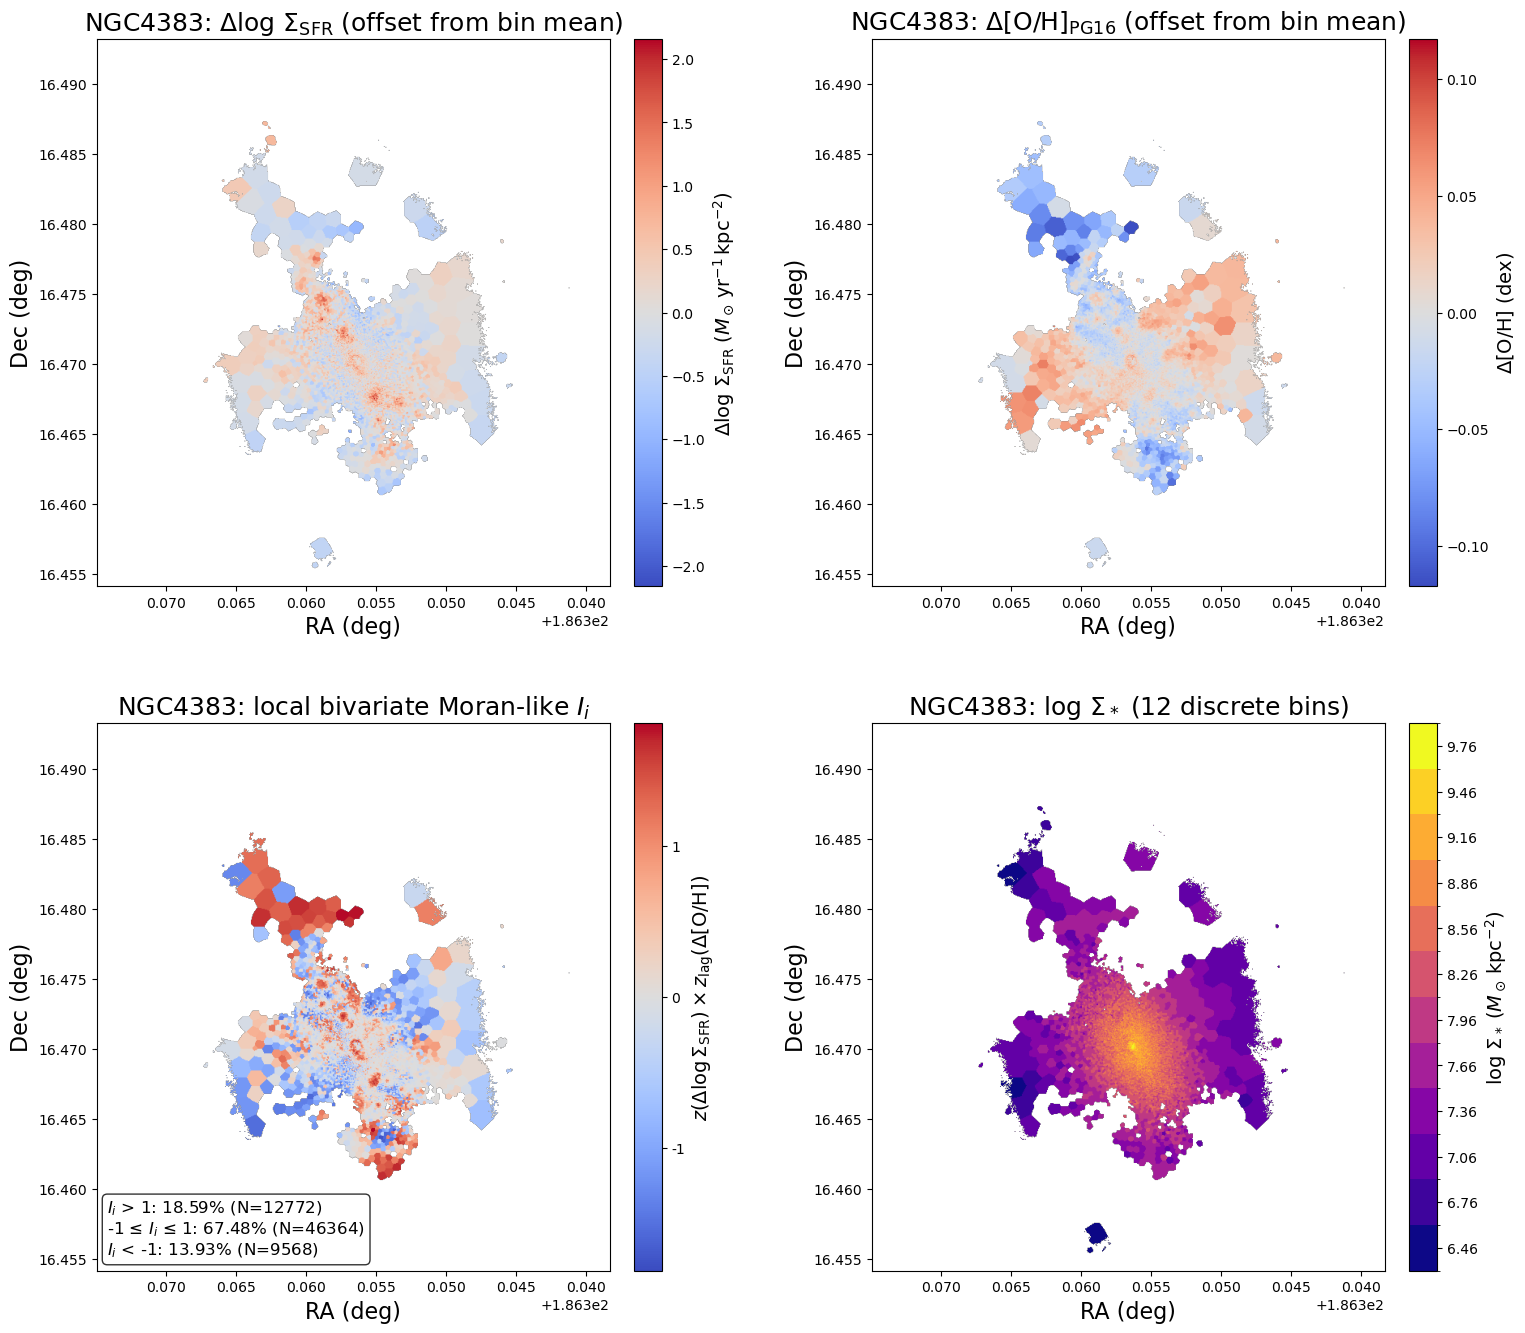


2x2 combined figure complete for NGC4383!
  Σ_SFR offset range: -2.161 to 2.161
  [O/H] offset range: -0.117 to 0.117
  Moran I_i range: -6.717 to 8.088
  Σ* bins: 12 bins from 6.315 to 9.905
  I_i > 1: 18.59% (N=12772)
  -1 ≤ I_i ≤ 1: 67.48% (N=46364)
  I_i < -1: 13.93% (N=9568)


In [12]:
# ------------------------------------------------------------------
# 2x2 Combined figure: offset maps + Moran-like map + binned Σ* map
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gs_module
from matplotlib.colors import BoundaryNorm, SymLogNorm

# Only focus on NGC4383 for this visualisation
galaxies = ['NGC4383']

# ------------------------------------------------------------------
# Define threshold parameter for linear/log colorbar transition and classification
# ------------------------------------------------------------------
threshold = 1  # Values between -threshold and +threshold use linear scale

# ------------------------------------------------------------------
# 1.  Helper: read the required maps
# ------------------------------------------------------------------
def load_maps(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
        binid_map = h_spatial['BINID'].data
        wcs = WCS(h_spatial['LOGMASS_SURFACE_DENSITY'].header)
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_PG16_HII' in h_gas:
            oh_map = h_gas['O_H_PG16_HII'].data
            indicator_name = 'PG16'
        elif 'O_H_D16_HII' in h_gas:
            print(f"Warning: PG16 not available for {gal}; using D16 instead.")
            oh_map = h_gas['O_H_D16_HII'].data
            indicator_name = 'D16'
        elif 'O_H_O3N2_M14_HII' in h_gas:
            print(f"Warning: PG16 and D16 not available for {gal}; using O3N2-M14 instead.")
            oh_map = h_gas['O_H_O3N2_M14_HII'].data
            indicator_name = 'O3N2-M14'
        elif 'O_H_O3N2_M13_HII' in h_gas:
            print(f"Warning: PG16, D16 and O3N2-M14 not available for {gal}; using O3N2-M13 instead.")
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
            indicator_name = 'O3N2-M13'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No metallicity extension (PG16/D16/O3N2-M14/O3N2-M13) found for {gal}. Available: {available}")
        gas_header = h_gas['LOGSFR_SURFACE_DENSITY_HII'].header
    return sigM, sigSFR, oh_map, indicator_name, wcs, gas_header, binid_map

for gal in galaxies:
    sigM, sigSFR, oh_o3n2_map, indicator_name, wcs_full, gas_header, binid_map = load_maps(gal)
    # Valid pixels across maps
    valid_sfr = np.isfinite(sigSFR)
    valid_oh = np.isfinite(oh_o3n2_map)
    valid_sigM = np.isfinite(sigM)
    valid_all = valid_sfr & valid_oh & valid_sigM

    # ------------------------------------------------------------------
    # 2.  Calculate offset maps (relative to Σ* bin means)
    # ------------------------------------------------------------------
    # Define 12 Σ* bins
    n_bins = 12
    sigmaM_min = np.nanmin(sigM[valid_all])
    sigmaM_max = np.nanmax(sigM[valid_all])
    sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)
    
    # Initialize offset maps
    sfr_offset = np.full_like(sigSFR, np.nan)
    oh_offset = np.full_like(oh_o3n2_map, np.nan)
    
    # Calculate offset for each Σ* bin
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        
        if np.sum(bin_mask) > 0:
            sfr_bin_mean = np.nanmean(sigSFR[bin_mask])
            oh_bin_mean = np.nanmean(oh_o3n2_map[bin_mask])
            
            sfr_offset[bin_mask] = sigSFR[bin_mask] - sfr_bin_mean
            oh_offset[bin_mask] = oh_o3n2_map[bin_mask] - oh_bin_mean
    
    sfr_offset_max = np.nanmax(np.abs(sfr_offset[valid_all]))
    oh_offset_max = np.nanmax(np.abs(oh_offset[valid_all]))
    
    # Global means for display purposes only
    sfr_mean = np.nanmean(sigSFR[valid_sfr])
    oh_mean = np.nanmean(oh_o3n2_map[valid_oh])

    # ------------------------------------------------------------------
    # 3.  Calculate local bivariate Moran-like map
    # ------------------------------------------------------------------
    def local_bivariate_moran_by_bin(A, B, valid_mask, binid_map, neighbourhood='queen'):
        """Local bivariate Moran-style statistic on adjacent spatial bins.

        Each valid BINID is treated as one graph node, using the mean A and B value
        of that bin. The resulting per-bin Moran value is expanded back to all
        valid pixels in the bin for plotting.
        """
        A = np.asarray(A, dtype=float)
        B = np.asarray(B, dtype=float)
        valid_mask = np.asarray(valid_mask, dtype=bool)
        binid_raw = np.asarray(binid_map, dtype=float)
        if A.shape != B.shape or A.shape != valid_mask.shape or A.shape != binid_raw.shape:
            raise ValueError('A, B, valid_mask, and binid_map must have the same shape')

        I_map = np.full(A.shape, np.nan)
        quad_map = np.zeros(A.shape, dtype=np.int16)
        finite_bin = np.isfinite(binid_raw) & (binid_raw >= 0)
        binid = np.full(A.shape, -1, dtype=np.int64)
        binid[finite_bin] = np.rint(binid_raw[finite_bin]).astype(np.int64)
        valid = valid_mask & np.isfinite(A) & np.isfinite(B) & (binid >= 0)
        valid_bins = np.unique(binid[valid])
        if valid_bins.size < 2:
            return I_map, quad_map

        max_bin = int(valid_bins.max())
        flat_bins = binid[valid].ravel()
        counts = np.bincount(flat_bins, minlength=max_bin + 1).astype(float)
        sum_A = np.bincount(flat_bins, weights=A[valid].ravel(), minlength=max_bin + 1)
        sum_B = np.bincount(flat_bins, weights=B[valid].ravel(), minlength=max_bin + 1)
        A_bin = np.full(max_bin + 1, np.nan)
        B_bin = np.full(max_bin + 1, np.nan)
        has_data = counts > 0
        A_bin[has_data] = sum_A[has_data] / counts[has_data]
        B_bin[has_data] = sum_B[has_data] / counts[has_data]

        A_vals = A_bin[valid_bins]
        B_vals = B_bin[valid_bins]
        A_std = np.nanstd(A_vals)
        B_std = np.nanstd(B_vals)
        if not np.isfinite(A_std) or not np.isfinite(B_std) or A_std == 0 or B_std == 0:
            return I_map, quad_map

        Az = np.full(max_bin + 1, np.nan)
        Bz = np.full(max_bin + 1, np.nan)
        Az[valid_bins] = (A_vals - np.nanmean(A_vals)) / A_std
        Bz[valid_bins] = (B_vals - np.nanmean(B_vals)) / B_std

        offsets = [(-1, 0), (1, 0), (0, -1), (0, 1)]
        if neighbourhood == 'queen':
            offsets += [(-1, -1), (-1, 1), (1, -1), (1, 1)]
        elif neighbourhood != 'rook':
            raise ValueError("neighbourhood must be 'rook' or 'queen'")

        adjacency = {int(b): set() for b in valid_bins}
        rows, cols = A.shape
        for dy, dx in offsets:
            y0 = max(0, -dy)
            y1 = rows - max(0, dy)
            x0 = max(0, -dx)
            x1 = cols - max(0, dx)
            src = (slice(y0, y1), slice(x0, x1))
            dst = (slice(y0 + dy, y1 + dy), slice(x0 + dx, x1 + dx))
            pair_valid = valid[src] & valid[dst] & (binid[src] != binid[dst])
            for left, right in zip(binid[src][pair_valid], binid[dst][pair_valid]):
                left = int(left)
                right = int(right)
                adjacency[left].add(right)
                adjacency[right].add(left)

        for b in valid_bins:
            b = int(b)
            neigh = sorted(adjacency[b])
            if not neigh:
                continue
            lag_B = np.nanmean(Bz[neigh])
            I_val = Az[b] * lag_B
            pixels = valid & (binid == b)
            I_map[pixels] = I_val
            if Az[b] >= 0 and lag_B >= 0:
                quad_map[pixels] = 1
            elif Az[b] < 0 and lag_B < 0:
                quad_map[pixels] = 2
            elif Az[b] >= 0 and lag_B < 0:
                quad_map[pixels] = 3
            else:
                quad_map[pixels] = 4

        return I_map, quad_map
    I_map, quad_map = local_bivariate_moran_by_bin(sfr_offset, oh_offset, valid_all, binid_map,
                                            neighbourhood='queen')

    # ------------------------------------------------------------------
    # Calculate statistics for three classes based on threshold
    # ------------------------------------------------------------------
    valid_I = np.isfinite(I_map)
    n_total = np.sum(valid_I)
    n_high = np.sum(I_map[valid_I] > threshold)
    n_mid = np.sum((I_map[valid_I] >= -threshold) & (I_map[valid_I] <= threshold))
    n_low = np.sum(I_map[valid_I] < -threshold)
    pct_high = (n_high / n_total * 100) if n_total > 0 else 0
    pct_mid = (n_mid / n_total * 100) if n_total > 0 else 0
    pct_low = (n_low / n_total * 100) if n_total > 0 else 0

    # ------------------------------------------------------------------
    # 4.  Create binned Σ* map
    # ------------------------------------------------------------------
    sigM_binned_map = np.full_like(sigM, np.nan)
    
    for i in range(n_bins):
        if i == 0:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        elif i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        
        # Assign bin center value
        bin_center = (sigmaM_bin_edges[i] + sigmaM_bin_edges[i+1]) / 2
        sigM_binned_map[bin_mask] = bin_center

    # ------------------------------------------------------------------
    # 5.  Prepare coordinate extent
    # ------------------------------------------------------------------
    wcs_celestial = WCS(gas_header).celestial
    y_size, x_size = sigSFR.shape
    x_coords = np.arange(x_size)
    y_coords = np.arange(y_size)
    xx, yy = np.meshgrid(x_coords, y_coords)
    ra, dec = wcs_celestial.pixel_to_world_values(xx, yy)
    extent = [ra.max(), ra.min(), dec.min(), dec.max()]

    # ------------------------------------------------------------------
    # 6.  Create 2x2 figure
    # ------------------------------------------------------------------
    fig = plt.figure(figsize=(18, 16))
    gs = gs_module.GridSpec(2, 2, figure=fig, hspace=0.25, wspace=0.25)

    # Top-left: Σ_SFR offset map
    ax1 = fig.add_subplot(gs[0, 0])
    im_sfr = ax1.imshow(np.ma.masked_invalid(sfr_offset), origin='lower', cmap='coolwarm',
                        extent=extent, vmin=-sfr_offset_max, vmax=sfr_offset_max)
    ax1.set_title(rf'{gal}: $\Delta\log\,\Sigma_{{\mathrm{{SFR}}}}$ (offset from bin mean)', fontsize=18)
    ax1.set_xlabel('RA (deg)', fontsize=16)
    ax1.set_ylabel('Dec (deg)', fontsize=16)
    
    cbar_sfr = fig.colorbar(im_sfr, ax=ax1, fraction=0.046, pad=0.04)
    cbar_sfr.set_label(r'$\Delta\log\,\Sigma_{\mathrm{SFR}} \; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=14)

    # Top-right: [O/H] offset map
    ax2 = fig.add_subplot(gs[0, 1])
    im_oh = ax2.imshow(np.ma.masked_invalid(oh_offset), origin='lower', cmap='coolwarm',
                       extent=extent, vmin=-oh_offset_max, vmax=oh_offset_max)
    ax2.set_title(rf'{gal}: $\Delta$[O/H]$_{{\mathrm{{{indicator_name}}}}}$ (offset from bin mean)', fontsize=18)
    ax2.set_xlabel('RA (deg)', fontsize=16)
    ax2.set_ylabel('Dec (deg)', fontsize=16)
    
    cbar_oh = fig.colorbar(im_oh, ax=ax2, fraction=0.046, pad=0.04)
    cbar_oh.set_label(r'$\Delta$[O/H] (dex)', fontsize=14)

    # Bottom-left: Moran-like bivariate map with SymLogNorm
    ax3 = fig.add_subplot(gs[1, 0])
    
    # max absolute value for symmetric limits
    vI = np.nanmax(np.abs(I_map))
    
    # Symmetric log-normalisation using threshold parameter:
    #  - values between -threshold and +threshold are on a linear scale
    #  - outside this, log10 scaling, symmetric around 0
    norm = SymLogNorm(linthresh=threshold, linscale=1.0,
                      vmin=-vI, vmax=vI, base=10)
    
    imI = ax3.imshow(np.ma.masked_invalid(I_map), origin='lower',
                     cmap='coolwarm', extent=extent, norm=norm)
    ax3.set_title(rf'{gal}: local bivariate Moran-like $I_i$', fontsize=18)
    ax3.set_xlabel('RA (deg)', fontsize=16)
    ax3.set_ylabel('Dec (deg)', fontsize=16)
    
    cbarI = fig.colorbar(imI, ax=ax3, fraction=0.046, pad=0.04)
    cbarI.set_label(r'$z(\Delta\log\Sigma_{\rm SFR}) \times z_{\rm lag}(\Delta{\rm [O/H]})$', fontsize=14)
    
    # Symmetric log-style ticks including ±threshold
    # Build positive log ticks
    max_pow = int(np.floor(np.log10(vI)))
    pos_ticks = [10**k for k in range(0, max_pow+1) if 10**k <= vI]
    
    # Combine: negative log ticks + -threshold + 0 + threshold + positive log ticks
    # Remove threshold from pos_ticks if it's already a power of 10
    pos_ticks_filtered = [p for p in pos_ticks if p != threshold]
    neg_ticks_filtered = [-p for p in reversed(pos_ticks_filtered)]
    
    ticks = neg_ticks_filtered + [-threshold, 0.0, threshold] + pos_ticks_filtered
    # Sort and remove duplicates
    ticks = sorted(set(ticks))
    
    cbarI.set_ticks(ticks)
    cbarI.set_ticklabels([f'{t:g}' for t in ticks])
    
    # Add legend for three classes based on threshold
    # Find best location by checking which corner has most NaN values
    ny, nx = I_map.shape
    corner_size = min(ny // 4, nx // 4)  # Check a quarter of the image size
    
    # Count NaN pixels in each corner
    corners = {
        'bottom_left': np.sum(np.isnan(I_map[:corner_size, :corner_size])),
        'bottom_right': np.sum(np.isnan(I_map[:corner_size, -corner_size:])),
        'top_left': np.sum(np.isnan(I_map[-corner_size:, :corner_size])),
        'top_right': np.sum(np.isnan(I_map[-corner_size:, -corner_size:]))
    }
    
    # Choose corner with most NaN values
    best_corner = max(corners, key=corners.get)
    
    # Set position and alignment based on best corner
    if best_corner == 'bottom_left':
        x_pos, y_pos = 0.02, 0.02
        va, ha = 'bottom', 'left'
    elif best_corner == 'bottom_right':
        x_pos, y_pos = 0.98, 0.02
        va, ha = 'bottom', 'right'
    elif best_corner == 'top_left':
        x_pos, y_pos = 0.02, 0.98
        va, ha = 'top', 'left'
    else:  # top_right
        x_pos, y_pos = 0.98, 0.98
        va, ha = 'top', 'right'
    
    legend_text = f'$I_i$ > {threshold}: {pct_high:.2f}% (N={n_high})\n-{threshold} ≤ $I_i$ ≤ {threshold}: {pct_mid:.2f}% (N={n_mid})\n$I_i$ < -{threshold}: {pct_low:.2f}% (N={n_low})'
    ax3.text(x_pos, y_pos, legend_text, transform=ax3.transAxes, 
            fontsize=12, verticalalignment=va, horizontalalignment=ha,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # Bottom-right: Discrete Σ* binned map
    ax4 = fig.add_subplot(gs[1, 1])
    
    cmap_discrete = plt.cm.plasma
    norm_discrete = BoundaryNorm(sigmaM_bin_edges, cmap_discrete.N)
    
    im_sigM_binned = ax4.imshow(np.ma.masked_invalid(sigM_binned_map), origin='lower', 
                                cmap=cmap_discrete, norm=norm_discrete, extent=extent)
    ax4.set_title(rf'{gal}: $\log\,\Sigma_*$ ({n_bins} discrete bins)', fontsize=18)
    ax4.set_xlabel('RA (deg)', fontsize=16)
    ax4.set_ylabel('Dec (deg)', fontsize=16)
    
    cbar_binned = fig.colorbar(im_sigM_binned, ax=ax4, fraction=0.046, pad=0.04)
    cbar_binned.set_label(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=14)
    
    # Set colorbar ticks at bin centers
    bin_centers = [(sigmaM_bin_edges[i] + sigmaM_bin_edges[i+1]) / 2 for i in range(n_bins)]
    cbar_binned.set_ticks(bin_centers)
    cbar_binned.set_ticklabels([f'{bc:.2f}' for bc in bin_centers])

    plt.tight_layout()
    # plt.savefig(f'{gal}_correlation_map_moran.png', dpi=600, bbox_inches='tight')
    # plt.savefig(f'{gal}_correlation_map_moran.pdf', bbox_inches='tight')
    plt.show()

    print(f"\n2x2 combined figure complete for {gal}!")
    print(f"  Σ_SFR offset range: {-sfr_offset_max:.3f} to {sfr_offset_max:.3f}")
    print(f"  [O/H] offset range: {-oh_offset_max:.3f} to {oh_offset_max:.3f}")
    print(f"  Moran I_i range: {np.nanmin(I_map):.3f} to {np.nanmax(I_map):.3f}")
    print(f"  Σ* bins: {n_bins} bins from {sigmaM_min:.3f} to {sigmaM_max:.3f}")
    print(f"  I_i > {threshold}: {pct_high:.2f}% (N={n_high})")
    print(f"  -{threshold} ≤ I_i ≤ {threshold}: {pct_mid:.2f}% (N={n_mid})")
    print(f"  I_i < -{threshold}: {pct_low:.2f}% (N={n_low})")
